In [1]:
%matplotlib qt

In [3]:
%matplotlib inline

In [ ]:
# mbes_detrend_autotune.py
# Requirements: pip install numpy rasterio scipy matplotlib

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple, Iterable, Dict, Any, List
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.stats import median_abs_deviation


# --------------------------- helpers -----------------------------------------


def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    """Pad axes limits and keep meters equal with a data-driven box aspect
    so tall/skinny swaths don't render as half a figure."""
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    if equal_aspect:
        ax.set_aspect("equal", adjustable="datalim")
        try:
            ax.set_box_aspect(yr / xr)
        except Exception:
            pass
    try:
        ax.ticklabel_format(style="plain", axis="both", useOffset=False)
    except Exception:
        pass


def _robust_sym_vlim(arr, q=0.98):
    m = np.isfinite(arr)
    if not m.any():
        return (-1, 1)
    lo, hi = np.nanquantile(arr[m], [(1 - q) / 2, 1 - (1 - q) / 2])
    vmax = max(abs(lo), abs(hi))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = (np.nanstd(arr[m]) or 1.0) * 3
    return (-vmax, vmax)


def _rows_from_meters(pix_size_y, meters, poly=2):
    n = max(5, int(round((meters or 0.0) / max(abs(pix_size_y) or 1.0, 1e-9))))
    if n % 2 == 0:
        n += 1
    if n <= poly + 2:
        n = poly + 3 if (poly + 3) % 2 == 1 else poly + 4
    return n


def _savgol_nanaware(arr, pix_size_y, meters, poly=2):
    """Savitzky–Golay smoothing with NaN handling; falls back to Gaussian."""
    a = np.asarray(arr, float)
    valid = np.isfinite(a)
    if valid.sum() < 3:
        return a.copy()

    nwin = _rows_from_meters(pix_size_y, meters, poly=poly)

    if valid.sum() < nwin:
        tmp = a.copy()
        tmp[~valid] = 0.0
        w = valid.astype(float)
        sigma = max(0.5, nwin / 6)
        num = gaussian_filter1d(tmp, sigma=sigma, mode="reflect", truncate=3.5)
        den = gaussian_filter1d(w, sigma=sigma, mode="reflect", truncate=3.5)
        out = np.where(den > 1e-6, num / den, np.nan)
        out[~valid] = np.nan
        return out

    filled = a.copy()
    if (~valid).any():
        idx = np.arange(filled.size)
        filled[~valid] = np.interp(idx[~valid], idx[valid], filled[valid])
    out = savgol_filter(filled, window_length=nwin, polyorder=poly, mode="interp")
    return out


def _second_diff_roughness(series: np.ndarray) -> float:
    """Small number when the curve is smooth; scale-free-ish."""
    s = np.asarray(series, float)
    s = s[np.isfinite(s)]
    if s.size < 5:
        return np.inf
    d2 = np.diff(s, n=2)
    return float(np.nanmedian(np.abs(d2)))


# --------------------------- main class --------------------------------------


@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0

    # smoothing scales (meters, along-track)
    smooth_baseline_m: float = 10.0  # A(y)
    smooth_tilt_m: float = 20.0  # B(y)
    smooth_curv_m: Optional[float] = None  # C(y); if None -> use tilt_m
    smooth_center_m: float = 6.0  # x̄(y)

    # robust fit options
    max_row_iters: int = 3
    clip_sigma: float = 6.0
    central_frac: float = 0.8  # central fraction of beams used in per-row fits

    # internals (filled by load/detrend)
    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None

    # fitted sequences
    A: Optional[np.ndarray] = None
    B: Optional[np.ndarray] = None
    C: Optional[np.ndarray] = None
    D: Optional[np.ndarray] = None  # cubic term for order_x=3
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    D_s: Optional[np.ndarray] = None
    x_center_row: Optional[np.ndarray] = None
    x_center_s: Optional[np.ndarray] = None

    # results
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None
    used_order: int = 0  # the actual polynomial order used when detrending

    # --- I/O ---
    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            b = src.bounds

        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.valid_mask = np.isfinite(z)
        self.data = z
        self.transform = tf
        self.extent = (float(b.left), float(b.right), float(b.bottom), float(b.top))

        a, _, c, _, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        return self

    # --- detrend ---
    def detrend(
        self,
        order_x: int = 2,  # 0..3 supported
        remove_cross_track_tilt: bool = True,
        robust: bool = True,
        smooth_baseline_m: Optional[float] = None,
        smooth_tilt_m: Optional[float] = None,
        smooth_curv_m: Optional[float] = None,
        smooth_center_m: Optional[float] = None,
        central_frac: Optional[float] = None,
    ):
        if self.data is None:
            self.load()

        if smooth_baseline_m is not None:
            self.smooth_baseline_m = float(smooth_baseline_m)
        if smooth_tilt_m is not None:
            self.smooth_tilt_m = float(smooth_tilt_m)
        if smooth_curv_m is not None:
            self.smooth_curv_m = float(smooth_curv_m)
        if smooth_center_m is not None:
            self.smooth_center_m = float(smooth_center_m)
        if central_frac is not None:
            self.central_frac = float(central_frac)
        if self.smooth_curv_m is None:
            self.smooth_curv_m = self.smooth_tilt_m

        Z = self.data
        x = self.x_cols
        H, W = Z.shape

        # choose polynomial degree actually used
        deg = min(max(int(order_x), 0), 3)
        if not remove_cross_track_tilt:
            deg = 0
        self.used_order = deg

        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)
        D = np.full(H, 0.0)
        x_center = np.full(H, np.nan)

        # per-row robust polynomial around each row's median x
        for i in range(H):
            row = Z[i, :]
            m = np.isfinite(row)
            if m.sum() < max(6, 3 * (deg + 1)):
                continue

            xv = x[m]
            yv = row[m]

            xc_row = np.median(xv)  # avoid extrapolation when swath shifts laterally
            x_center[i] = xc_row

            if 0 < self.central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * self.central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * self.central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row
            coef = np.polyfit(xi, yv, deg)  # highest power first

            # convert to a0 + a1*xi + a2*xi^2 + a3*xi^3
            if deg == 0:
                a0, a1, a2, a3 = float(coef[0]), 0.0, 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = a3 = 0.0
            elif deg == 2:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])
                a3 = 0.0
            else:
                a3, a2, a1, a0 = (
                    float(coef[0]),
                    float(coef[1]),
                    float(coef[2]),
                    float(coef[3]),
                )

            if robust and deg > 0:
                for _ in range(self.max_row_iters):
                    # design matrix
                    X = [np.ones_like(xi)]
                    if deg >= 1:
                        X.append(xi)
                    if deg >= 2:
                        X.append(xi**2)
                    if deg >= 3:
                        X.append(xi**3)
                    X = np.vstack(X)
                    beta = np.array([a0, a1, a2, a3][: deg + 1])

                    pred = X.T @ beta
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)  # gentle robust weights

                    XtW = X * w  # broadcast
                    beta = np.linalg.lstsq(XtW.T, (yv * w), rcond=None)[0]
                    # pad to length 4 for consistency
                    pad = np.zeros(4)
                    pad[: beta.size] = beta
                    a0, a1, a2, a3 = pad

            A[i], B[i], C[i], D[i] = (
                a0,
                (a1 if deg >= 1 else 0.0),
                (a2 if deg >= 2 else 0.0),
                (a3 if deg >= 3 else 0.0),
            )

        # clip crazy rows, fill short gaps
        def _clip_and_fill(arr):
            s = arr.copy()
            m = np.isfinite(s)
            if m.sum() < 5:
                return s
            med = np.nanmedian(s[m])
            mad = median_abs_deviation(s[m], scale="normal")
            if not np.isfinite(mad) or mad == 0:
                mad = np.nanstd(s[m]) or 1.0
            lo, hi = med - self.clip_sigma * mad, med + self.clip_sigma * mad
            s[(s < lo) | (s > hi)] = np.nan
            idx = np.arange(len(s))
            good = np.isfinite(s)
            if good.sum() >= 2:
                s[~good] = np.interp(idx[~good], idx[good], s[good])
            return s

        A = _clip_and_fill(A)
        B = _clip_and_fill(B)
        C = _clip_and_fill(C)
        D = _clip_and_fill(D)
        x_center = _clip_and_fill(x_center)

        # along-track smoothing (edge safe)
        A_s = _savgol_nanaware(A, self.px_y, self.smooth_baseline_m, poly=2)
        B_s = (
            _savgol_nanaware(B, self.px_y, self.smooth_tilt_m, poly=2)
            if deg >= 1
            else None
        )
        C_s = (
            _savgol_nanaware(C, self.px_y, self.smooth_curv_m, poly=2)
            if deg >= 2
            else None
        )
        D_s = (
            _savgol_nanaware(D, self.px_y, self.smooth_curv_m, poly=2)
            if deg >= 3
            else None
        )
        Xc = _savgol_nanaware(x_center, self.px_y, self.smooth_center_m, poly=2)

        # reconstruct trend & residuals
        xi_full = self.x_cols[None, :] - Xc[:, None]
        trend = A_s[:, None]
        if deg >= 1:
            trend = trend + B_s[:, None] * xi_full
        if deg >= 2:
            trend = trend + C_s[:, None] * (xi_full**2)
        if deg >= 3:
            trend = trend + D_s[:, None] * (xi_full**3)

        if self.valid_mask is not None:
            trend = np.where(self.valid_mask, trend, np.nan)

        resid = self.data - trend
        resid[~np.isfinite(self.data)] = np.nan

        # store
        self.A, self.B, self.C, self.D = A, B, C, D
        self.A_s, self.B_s, self.C_s, self.D_s = A_s, B_s, C_s, D_s
        self.x_center_row, self.x_center_s = x_center, Xc
        self.trend, self.residuals = trend, resid
        return self

    # --- plotting ---
    def _extent(self):
        return (self.extent[0], self.extent[1], self.extent[2], self.extent[3])

    def _data_window(self, percentile=99.5):
        rows, cols = np.where(np.isfinite(self.data))
        if rows.size == 0:
            return self._extent()
        p_lo = (100 - percentile) / 2
        p_hi = 100 - p_lo
        c0 = int(np.percentile(cols, p_lo))
        c1 = int(np.percentile(cols, p_hi))
        r0 = int(np.percentile(rows, p_lo))
        r1 = int(np.percentile(rows, p_hi))
        x_min, x_max = self.x_cols[c0], self.x_cols[c1]
        y_min, y_max = self.y_rows[r1], self.y_rows[r0]
        return (x_min, x_max, y_min, y_max)

    def plot_triptych(
        self,
        cmap_orig="terrain",
        cmap_resid="RdBu_r",
        figsize=(9, 14),
        crop_to_data=True,
        bounds_percentile=99.5,
        margin_frac=0.03,
        equal_aspect=True,
    ):
        assert self.trend is not None, "Run detrend() first."
        fig, axs = plt.subplots(
            1, 3, figsize=figsize, constrained_layout=True, num="MBES Triptych"
        )

        im0 = axs[0].imshow(
            np.ma.masked_invalid(self.data),
            extent=self._extent(),
            origin="upper",
            cmap=cmap_orig,
        )
        axs[0].set_title("Original")
        axs[0].set_xlabel("Easting (m)")
        axs[0].set_ylabel("Northing (m)")
        fig.colorbar(im0, ax=axs[0], label="Depth (m)", fraction=0.035, pad=0.02)

        im1 = axs[1].imshow(
            np.ma.masked_invalid(self.trend),
            extent=self._extent(),
            origin="upper",
            cmap=cmap_orig,
        )
        axs[1].set_title(
            f"Estimated trend\norder={self.used_order}, base={self.smooth_baseline_m:.2f}m, tilt={self.smooth_tilt_m:.2f}m",
            fontsize=10,
        )
        axs[1].set_xlabel("Easting (m)")
        axs[1].set_ylabel("Northing (m)")
        fig.colorbar(im1, ax=axs[1], label="Depth (m)", fraction=0.035, pad=0.02)

        vmin, vmax = _robust_sym_vlim(self.residuals, q=0.98)
        im2 = axs[2].imshow(
            np.ma.masked_invalid(self.residuals),
            extent=self._extent(),
            origin="upper",
            cmap=cmap_resid,
            vmin=vmin,
            vmax=vmax,
        )
        axs[2].set_title("Residuals (local variations)")
        axs[2].set_xlabel("Easting (m)")
        axs[2].set_ylabel("Northing (m)")
        fig.colorbar(im2, ax=axs[2], label="m", fraction=0.035, pad=0.02)

        if crop_to_data:
            x_min, x_max, y_min, y_max = self._data_window(bounds_percentile)
        else:
            x_min, x_max, y_min, y_max = self._extent()

        for ax in axs:
            _pad_limits(
                ax,
                x_min,
                x_max,
                y_min,
                y_max,
                pad_frac=margin_frac,
                equal_aspect=equal_aspect,
            )

        plt.show(block=False)
        return fig

    def plot_residual_heatmap(
        self,
        figsize=(6, 14),
        cmap="RdBu_r",
        vmax=None,
        crop_to_data=True,
        bounds_percentile=99.5,
        margin_frac=0.03,
        equal_aspect=True,
        title_suffix="",
    ):
        assert self.residuals is not None, "Run detrend() first."
        if vmax is None:
            vmin, vmax = _robust_sym_vlim(self.residuals, q=0.98)
        else:
            vmin, vmax = -abs(vmax), abs(vmax)

        fig, ax = plt.subplots(
            1, 1, figsize=figsize, constrained_layout=True, num="MBES Residuals"
        )
        im = ax.imshow(
            np.ma.masked_invalid(self.residuals),
            extent=self._extent(),
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        if crop_to_data:
            x_min, x_max, y_min, y_max = self._data_window(bounds_percentile)
        else:
            x_min, x_max, y_min, y_max = self._extent()

        _pad_limits(
            ax,
            x_min,
            x_max,
            y_min,
            y_max,
            pad_frac=margin_frac,
            equal_aspect=equal_aspect,
        )
        settings = f"order={self.used_order}, base={self.smooth_baseline_m:.2f}m, tilt={self.smooth_tilt_m:.2f}m, center={self.smooth_center_m:.2f}m"
        ax.set_title(
            f"Detrended bathymetry (local variations)\n{settings}{(' — ' + title_suffix) if title_suffix else ''}",
            fontsize=10,
        )
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        fig.colorbar(im, ax=ax, label="m", fraction=0.035, pad=0.02)
        plt.show(block=False)
        return fig

    def plot_components(
        self, figsize=(10, 8), bounds_percentile=99.5, margin_frac=0.03
    ):
        assert self.A_s is not None, "Run detrend() first."
        y = self.y_rows
        fig, ax = plt.subplots(
            2, 2, figsize=figsize, constrained_layout=True, num="MBES Components"
        )

        ax[0, 0].plot(self.A, y, alpha=0.25, label="row fit")
        ax[0, 0].plot(self.A_s, y, lw=2, label="smoothed")
        ax[0, 0].invert_yaxis()
        ax[0, 0].set_title(f"A(y) baseline — σ={self.smooth_baseline_m:.2f}m")
        ax[0, 0].set_xlabel("Depth (m)")
        ax[0, 0].set_ylabel("Northing (m)")
        ax[0, 0].legend()

        ax[0, 1].plot(self.B, y, alpha=0.25, label="row fit")
        if self.B_s is not None:
            ax[0, 1].plot(self.B_s, y, lw=2, label="smoothed")
        ax[0, 1].invert_yaxis()
        ax[0, 1].set_title(f"B(y) tilt — σ={self.smooth_tilt_m:.2f}m")
        ax[0, 1].set_xlabel("Slope (m/m)")
        ax[0, 1].set_ylabel("Northing (m)")
        ax[0, 1].legend()

        # Bottom-left: C (and D if present)
        if self.used_order >= 2:
            ax[1, 0].plot(self.C, y, alpha=0.25, label="C row fit")
            ax[1, 0].plot(self.C_s, y, lw=2, label="C smoothed")
            if self.used_order >= 3:
                ax[1, 0].plot(self.D, y, alpha=0.25, label="D row fit")
                ax[1, 0].plot(self.D_s, y, lw=2, label="D smoothed")
            ax[1, 0].invert_yaxis()
            ax[1, 0].set_title(f"C/D(y) curvature/cubic — σ≈{self.smooth_curv_m:.2f}m")
            ax[1, 0].set_xlabel("1/m, 1/m²")
            ax[1, 0].set_ylabel("Northing (m)")
            ax[1, 0].legend()
        else:
            ax[1, 0].axis("off")

        # Bottom-right: swath center
        ax[1, 1].plot(self.x_center_row, y, alpha=0.25, label="row median x")
        ax[1, 1].plot(self.x_center_s, y, lw=2, label="smoothed")
        ax[1, 1].invert_yaxis()
        ax[1, 1].set_title(
            f"Swath center x̄(y) — σ={self.smooth_center_m:.2f}m, central={self.central_frac*100:.0f}%"
        )
        ax[1, 1].set_xlabel("Easting (m)")
        ax[1, 1].set_ylabel("Northing (m)")
        ax[1, 1].legend()

        # keep y range similar to map panels
        x_min, x_max, y_min, y_max = self._data_window(bounds_percentile)
        for a in ax.flat:
            a.set_ylim(
                y_min - (y_max - y_min) * margin_frac,
                y_max + (y_max - y_min) * margin_frac,
            )

        plt.show(block=False)
        return fig


# --------------------------- auto-tuner --------------------------------------


def score_solution(mb: MBESDetrender, thin_rows: int = 2) -> Dict[str, float]:
    """
    Compute a scalar score: lower = better.
    Components:
      - column banding (std of column medians)  -> penalizes striping/rings
      - residual std relative to original std   -> avoids 'too smooth to zero'
      - roughness of B_s and x_center_s         -> penalizes over-wiggly fits
    """
    Z0_std = np.nanstd(mb.data)
    R = mb.residuals
    if thin_rows > 1:
        R = R[::thin_rows, :]
    col_med = np.nanmedian(R, axis=0)
    banding = float(np.nanstd(col_med))

    rstd = float(np.nanstd(R))
    rough_B = _second_diff_roughness(mb.B_s) if mb.B_s is not None else 0.0
    rough_X = _second_diff_roughness(mb.x_center_s)

    # weights chosen to strongly prefer low striping, but keep variance & smoothness reasonable
    score = banding + 0.20 * (rstd / (Z0_std + 1e-9)) + 0.5 * rough_B + 0.2 * rough_X
    return dict(
        score=score, banding=banding, rstd=rstd, rough_B=rough_B, rough_X=rough_X
    )


def auto_tune(
    mb: MBESDetrender,
    orders: Iterable[int] = (1, 2),  # try 1 first; include 2 if needed
    base_grid_m: Iterable[float] = (0.3, 0.5, 0.8, 1.2),
    tilt_mult: Iterable[float] = (1.2, 1.6, 2.0),
    center_grid_m: Iterable[float] = (0.4, 0.8, 1.2),
    central_fracs: Iterable[float] = (0.8,),
    thin_rows: int = 2,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    Simple grid search that minimizes the 'score_solution' metric.
    Returns {'best': {...}, 'trials': list_of_dicts}.
    """
    trials: List[Dict[str, Any]] = []
    best: Dict[str, Any] = {"score": np.inf}

    for order in orders:
        for cf in central_fracs:
            for base in base_grid_m:
                for mul in tilt_mult:
                    tilt = base * mul
                    for center in center_grid_m:
                        mb.detrend(
                            order_x=order,
                            smooth_baseline_m=base,
                            smooth_tilt_m=tilt,
                            smooth_center_m=center,
                            central_frac=cf,
                            robust=True,
                        )
                        s = score_solution(mb, thin_rows=thin_rows)
                        trial = dict(
                            order=order,
                            central_frac=cf,
                            baseline_m=base,
                            tilt_m=tilt,
                            center_m=center,
                            **s,
                        )
                        trials.append(trial)
                        if verbose:
                            print(
                                f"[auto] order={order} cf={cf:.2f} base={base:.2f} tilt={tilt:.2f} center={center:.2f}  "
                                f"score={s['score']:.6g} band={s['banding']:.6g} rstd={s['rstd']:.6g} "
                                f"roughB={s['rough_B']:.3g} roughX={s['rough_X']:.3g}"
                            )
                        if s["score"] < best["score"]:
                            best = trial.copy()

    return {"best": best, "trials": trials}

    # --------------------------- example usage -----------------------------------

    # if __name__ == "__main__":
    plt.ion()

    # 1) Load
    tif = r"E:\mjosa_new\DTM\geotiff_2.tif"  # <-- change path if needed
    mb = MBESDetrender(tif).load()

    # 2a) Manual settings (you can comment this out when using auto_tune)
    mb.detrend(
        order_x=2,  # try 1 first; bump to 2 only if a broad bowl remains
        smooth_baseline_m=0.8,
        smooth_tilt_m=0.7,
        smooth_center_m=1.0,
        central_frac=0.8,
        robust=True,
    )
    mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
    mb.plot_components(figsize=(10, 8))
    mb.plot_residual_heatmap(figsize=(6, 14), equal_aspect=True, title_suffix="manual")

    # 2b) Auto-tune smoothing & order (small grid; expand if you want)
    print("\n🔧 Auto-tuning …")
    search = auto_tune(
        mb,
        orders=(1, 2),  # include 3 if you truly need cubic
        base_grid_m=(0.3, 0.5, 0.8, 1.2),
        tilt_mult=(1.2, 1.6, 2.0),
        center_grid_m=(0.4, 0.8, 1.2),
        central_fracs=(0.8,),
        thin_rows=2,  # evaluate score every 2nd row (faster)
        verbose=True,
    )
    best = search["best"]
    print("\n✅ Best:", best)

    # Re-run with the best settings on the full grid, then plot
    mb.detrend(
        order_x=int(best["order"]),
        smooth_baseline_m=float(best["baseline_m"]),
        smooth_tilt_m=float(best["tilt_m"]),
        smooth_center_m=float(best["center_m"]),
        central_frac=float(best["central_frac"]),
        robust=True,
    )
    mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
    mb.plot_components(figsize=(10, 8))
    mb.plot_residual_heatmap(
        figsize=(6, 14), equal_aspect=True, title_suffix="auto-tuned"
    )

    plt.show(block=True)

In [ ]:
if __name__ == "__main__":
    plt.ion()

    # 1) Load
    tif = r"E:\mjosa_new\DTM\geotiff_2.tif"  # <-- change path if needed
    mb = MBESDetrender(tif).load()

    # 2a) Manual settings (you can comment this out when using auto_tune)
    mb.detrend(
        order_x=2,  # try 1 first; bump to 2 only if a broad bowl remains
        smooth_baseline_m=0.8,
        smooth_tilt_m=0.7,
        smooth_center_m=1.0,
        central_frac=0.8,
        robust=True,
    )
    mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
    mb.plot_components(figsize=(10, 8))
    mb.plot_residual_heatmap(figsize=(6, 14), equal_aspect=True, title_suffix="manual")

    # 2b) Auto-tune smoothing & order (small grid; expand if you want)
    print("\n🔧 Auto-tuning …")
    search = auto_tune(
        mb,
        orders=(1, 2),  # include 3 if you truly need cubic
        base_grid_m=(0.3, 0.5, 0.8, 1.2),
        tilt_mult=(1.2, 1.6, 2.0),
        center_grid_m=(0.4, 0.8, 1.2),
        central_fracs=(0.8,),
        thin_rows=2,  # evaluate score every 2nd row (faster)
        verbose=True,
    )
    best = search["best"]
    print("\n✅ Best:", best)

    # Re-run with the best settings on the full grid, then plot
    mb.detrend(
        order_x=int(best["order"]),
        smooth_baseline_m=float(best["baseline_m"]),
        smooth_tilt_m=float(best["tilt_m"]),
        smooth_center_m=float(best["center_m"]),
        central_frac=float(best["central_frac"]),
        robust=True,
    )
    mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
    mb.plot_components(figsize=(10, 8))
    mb.plot_residual_heatmap(
        figsize=(6, 14), equal_aspect=True, title_suffix="auto-tuned"
    )

    plt.show(block=True)

In [5]:
# ====================== mbes_autotune.py (drop-in) ===========================
# Requires your MBESDetrender class (the one you're already using).
# Paste this file after that class, or import it next to it.

import json
import math
import time
import csv
import os
from dataclasses import dataclass, asdict
from typing import Dict, Tuple, List, Optional
import numpy as np


# ---------- robust stats & diagnostics ---------------------------------------


def _nanmad(a):
    a = np.asarray(a, float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan
    med = np.median(a)
    return np.median(np.abs(a - med))


def _robust_std(a):
    m = _nanmad(a)
    return 1.4826 * m if np.isfinite(m) else np.nan


def _finite(a):
    return np.asarray(a, float)[np.isfinite(a)]


def _column_profile(resid, edge_clip_cols=0):
    """Robust column template (median per column)."""
    z = resid.copy()
    if edge_clip_cols > 0:
        z[:, :edge_clip_cols] = np.nan
        z[:, -edge_clip_cols:] = np.nan
    return np.nanmedian(z, axis=0)


def _edge_bias_metric(resid, center_frac=0.6):
    """
    Penalize red-center/blue-edge pattern by comparing mean residuals in
    the middle band vs edges. Returns |mean_center - mean_edges| / robust_std.
    """
    rstd = _robust_std(resid)
    if not np.isfinite(rstd) or rstd == 0:
        return 0.0

    H, W = resid.shape
    c0 = int((1.0 - center_frac) * 0.5 * W)
    c1 = W - c0
    col_med = np.nanmedian(resid, axis=0)

    center = _finite(col_med[c0:c1])
    edge = (
        _finite(np.concatenate([col_med[:c0], col_med[c1:]]))
        if c0 > 0
        else np.array([])
    )
    if center.size == 0 or edge.size == 0:
        return 0.0
    return abs(np.nanmedian(center) - np.nanmedian(edge)) / (rstd + 1e-9)


def _banding_metric(resid):
    """Stripe/banding measure: std of column medians normalized by robust std."""
    col_med = np.nanmedian(resid, axis=0)
    num = np.nanstd(col_med)
    den = _robust_std(resid)
    return float(num / (den + 1e-9)) if np.isfinite(den) else 0.0


def _roughness(v):
    """Along-track roughness of a 1D sequence (median absolute gradient)."""
    v = _finite(v)
    if v.size < 3:
        return 0.0
    g = np.diff(v)
    return float(np.nanmedian(np.abs(g)))


# ---------- search space utilities -------------------------------------------


def _unique_key(d: Dict) -> str:
    """Stable key for a params dict so we can de-dup across runs."""
    return json.dumps({k: d[k] for k in sorted(d)}, sort_keys=True)


def _coarse_space() -> List[Dict]:
    """Coarse grid for first pass (safe defaults)."""
    space = []
    for order in [1, 2, 3]:
        for central_frac in [0.6, 0.8, 1.0]:
            for base in [0.2, 0.4, 0.8, 1.6]:
                for tilt in [0.2, 0.4, 0.8, 1.6]:
                    for center in [0.2, 0.4, 0.8, 1.6]:
                        space.append(
                            dict(
                                order=order,
                                central_frac=central_frac,
                                baseline_m=base,
                                tilt_m=tilt,
                                center_m=center,
                            )
                        )
    return space


def _neighbors(around: Dict) -> List[Dict]:
    """Local neighborhood to refine around the current best."""
    mults = [0.6, 0.8, 1.0, 1.25, 1.6]
    orders = [max(1, min(3, around["order"] + d)) for d in [-1, 0, 1]]
    cfracs = sorted(
        set(
            [
                max(0.5, min(1.0, around["central_frac"] + d))
                for d in [-0.2, -0.1, 0, +0.1, +0.2]
            ]
        )
    )
    out = []
    for o in orders:
        for cf in cfracs:
            for mb in mults:
                for mt in mults:
                    for mc in mults:
                        out.append(
                            dict(
                                order=o,
                                central_frac=cf,
                                baseline_m=max(0.05, around["baseline_m"] * mb),
                                tilt_m=max(0.05, around["tilt_m"] * mt),
                                center_m=max(0.05, around["center_m"] * mc),
                            )
                        )
    return out


# ---------- scorer ------------------------------------------------------------


@dataclass
class ScoreWeights:
    # Lower is better for all terms
    w_rstd: float = 1.0  # robust residual std
    w_banding: float = 1.0  # column-banding
    w_edge_bias: float = 2.0  # center-vs-edge bias (high to kill red/blue sides)
    w_rough_B: float = 0.25  # roughness of B(y) (tilt)
    w_rough_X: float = 0.25  # roughness of x̄(y) (center track)


@dataclass
class RunResult:
    params: Dict
    score: float
    diagnostics: Dict


def _score_mb(mb, weights: ScoreWeights, edge_clip_cols: int = 0) -> RunResult:
    """Compute objective and helpful diagnostics for one detrend run."""
    resid = mb.residuals
    assert resid is not None

    # core terms
    rstd = _robust_std(resid)
    banding = _banding_metric(resid)
    edge_bias = _edge_bias_metric(resid, center_frac=0.6)

    # smoothness of trends (avoid overfitting the rigid/zig-zag lines)
    rough_B = _roughness(getattr(mb, "B_s", None))
    rough_X = _roughness(getattr(mb, "x_center_s", None))

    # final score (all positive; lower is better)
    score = (
        weights.w_rstd * rstd
        + weights.w_banding * banding
        + weights.w_edge_bias * edge_bias
        + weights.w_rough_B * (rough_B if np.isfinite(rough_B) else 0.0)
        + weights.w_rough_X * (rough_X if np.isfinite(rough_X) else 0.0)
    )
    diags = dict(
        rstd=rstd,
        banding=banding,
        edge_bias=edge_bias,
        rough_B=rough_B,
        rough_X=rough_X,
    )
    return RunResult(params={}, score=float(score), diagnostics=diags)


# ---------- main tuner --------------------------------------------------------


class AutoTuneMBES:
    """
    Usage:
        mb = MBESDetrender(tif).load()
        tuner = AutoTuneMBES(mb)
        best = tuner.fit(max_rounds=3, resume=True)
        tuner.apply_best_and_plot()

    The tuner will:
      1) run a coarse grid
      2) refine around the best a few rounds
      3) log to CSV and resume if you re-run
    """

    def __init__(
        self,
        mbes: "MBESDetrender",
        weights: ScoreWeights = ScoreWeights(),
        log_csv: str = "mbes_tuning_log.csv",
    ):
        self.src_path = mbes.tif_path if hasattr(mbes, "tif_path") else mbes.path
        self.log_csv = log_csv
        self.weights = weights
        self.tried = {}  # key -> (score, params, diags)
        self.best: Optional[RunResult] = None
        self.best_params: Optional[Dict] = None

    # ---- logging/resume ----
    def _write_row(self, params: Dict, res: RunResult):
        header = [
            "order",
            "central_frac",
            "baseline_m",
            "tilt_m",
            "center_m",
            "score",
            "rstd",
            "banding",
            "edge_bias",
            "rough_B",
            "rough_X",
        ]
        exists = os.path.exists(self.log_csv)
        with open(self.log_csv, "a", newline="") as f:
            w = csv.writer(f)
            if not exists:
                w.writerow(header)
            w.writerow(
                [
                    params["order"],
                    params["central_frac"],
                    params["baseline_m"],
                    params["tilt_m"],
                    params["center_m"],
                    res.score,
                    res.diagnostics.get("rstd"),
                    res.diagnostics.get("banding"),
                    res.diagnostics.get("edge_bias"),
                    res.diagnostics.get("rough_B"),
                    res.diagnostics.get("rough_X"),
                ]
            )

    def _load_tried(self):
        if not os.path.exists(self.log_csv):
            return
        with open(self.log_csv, "r", newline="") as f:
            r = csv.DictReader(f)
            for row in r:
                params = {
                    "order": int(float(row["order"])),
                    "central_frac": float(row["central_frac"]),
                    "baseline_m": float(row["baseline_m"]),
                    "tilt_m": float(row["tilt_m"]),
                    "center_m": float(row["center_m"]),
                }
                key = _unique_key(params)
                self.tried[key] = (float(row["score"]), params, {})  # diags unused

    # ---- 1 run ----
    def _run_once(self, params: Dict) -> RunResult:
        # fresh instance each time to avoid state carryover
        mb = MBESDetrender(self.src_path).load()
        mb.detrend(
            order_x=params["order"],
            smooth_baseline_m=params["baseline_m"],
            smooth_tilt_m=params["tilt_m"],
            smooth_center_m=params["center_m"],
            robust=True,
            central_frac=params["central_frac"],
        )
        res = _score_mb(mb, self.weights)
        res.params = params
        return res

    # ---- fit ----
    def fit(self, max_rounds: int = 3, resume: bool = True) -> Dict:
        if resume:
            self._load_tried()

        # Coarse pass
        space = _coarse_space()
        for p in space:
            key = _unique_key(p)
            if key in self.tried:
                continue
            res = self._run_once(p)
            self.tried[key] = (res.score, p, res.diagnostics)
            self._write_row(p, res)

        # Best so far
        best_key, (best_score, best_params, _) = min(
            self.tried.items(), key=lambda kv: kv[1][0]
        )
        self.best_params = best_params
        print(f"🔎 Coarse best: {best_params}  →  score={best_score:.6f}")

        # Local refinements
        for round_idx in range(max_rounds):
            improved = False
            for p in _neighbors(self.best_params):
                key = _unique_key(p)
                if key in self.tried:
                    continue
                res = self._run_once(p)
                self.tried[key] = (res.score, p, res.diagnostics)
                self._write_row(p, res)
                if res.score < best_score - 1e-6:
                    improved = True
                    best_score = res.score
                    self.best_params = p
                    print(
                        f"  ✅ Round {round_idx+1}: better → {p}  score={best_score:.6f}"
                    )
            if not improved:
                print(f"⏹️  Stopped after round {round_idx+1}: no improvement.")
                break

        self.best = RunResult(params=self.best_params, score=best_score, diagnostics={})
        print(f"🏁 Best params: {self.best_params}  score={best_score:.6f}")
        return self.best_params

    # ---- apply best & plot ----
    def apply_best_and_plot(self):
        assert self.best_params is not None, "Run .fit() first."
        mb = MBESDetrender(self.src_path).load()
        p = self.best_params
        mb.detrend(
            order_x=p["order"],
            smooth_baseline_m=p["baseline_m"],
            smooth_tilt_m=p["tilt_m"],
            smooth_center_m=p["center_m"],
            robust=True,
            central_frac=p["central_frac"],
        )
        print("📈 Plotting with best params...")
        mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
        mb.plot_components(figsize=(10, 8))
        mb.plot_residual_heatmap(figsize=(6, 14), equal_aspect=True)
        return mb


# --------------------------- example / CLI -----------------------------------
if __name__ == "__main__":
    # If you run this file directly, it will tune and plot.
    import matplotlib.pyplot as plt

    plt.ion()

    # Change this path if needed:
    tif = r"E:\mjosa_new\DTM\geotiff_2.tif"
    base = MBESDetrender(tif).load()

    tuner = AutoTuneMBES(
        base,
        weights=ScoreWeights(
            w_rstd=1.0,
            w_banding=1.0,
            w_edge_bias=2.5,  # ← strong penalty for red-center/blue-edges
            w_rough_B=0.3,
            w_rough_X=0.3,
        ),
    )
    best = tuner.fit(max_rounds=3, resume=True)
    mb_best = tuner.apply_best_and_plot()
    plt.show(block=True)
# ============================================================================

KeyboardInterrupt: 

In [6]:
# ====================== mbes_autotune_fast.py (drop-in) ======================
# Uses the MBESDetrender class you already have.

import os, csv, json, time, math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import numpy as np

# ---------------- robust helpers ----------------


def _nanmad(a):
    a = np.asarray(a, float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan
    med = np.median(a)
    return np.median(np.abs(a - med))


def _robust_std(a):
    m = _nanmad(a)
    return 1.4826 * m if np.isfinite(m) else np.nan


def _finite(a):
    return np.asarray(a, float)[np.isfinite(a)]


def _banding_metric(resid):
    """Stripe strength: std of column medians normalized by robust std."""
    col_med = np.nanmedian(resid, axis=0)
    num = np.nanstd(col_med)
    den = _robust_std(resid)
    return float(num / (den + 1e-9)) if np.isfinite(den) else 0.0


def _edge_bias_metric(resid, center_frac=0.6):
    """Red-center/blue-edge detector (lower is better)."""
    rstd = _robust_std(resid)
    if not np.isfinite(rstd) or rstd == 0:
        return 0.0
    H, W = resid.shape
    c0 = int((1.0 - center_frac) * 0.5 * W)
    c1 = W - c0
    col_med = np.nanmedian(resid, axis=0)
    center = _finite(col_med[c0:c1])
    edge = (
        _finite(np.concatenate([col_med[:c0], col_med[c1:]]))
        if c0 > 0
        else np.array([])
    )
    if center.size == 0 or edge.size == 0:
        return 0.0
    return abs(np.nanmedian(center) - np.nanmedian(edge)) / (rstd + 1e-9)


def _roughness(v):
    """Median |gradient| as a smoothness penalty."""
    v = _finite(v)
    if v.size < 3:
        return 0.0
    return float(np.nanmedian(np.abs(np.diff(v))))


# ---------------- search space ------------------


def _unique_key(d: Dict) -> str:
    return json.dumps({k: d[k] for k in sorted(d)}, sort_keys=True)


def _coarse_space(mode: str = "MEDIUM") -> List[Dict]:
    """
    LITE   :  72 combos
    MEDIUM : 162 combos  (default)
    FULL   : 576 combos  (can take a while)
    """
    if mode.upper() == "LITE":
        orders = [1, 2]
        cfracs = [0.7, 0.9]
        bases = [0.4, 0.8, 1.6]
        tilts = [0.4, 0.8, 1.6]
        centers = [0.4, 0.8, 1.6]
    elif mode.upper() == "FULL":
        orders = [1, 2, 3]
        cfracs = [0.6, 0.8, 1.0]
        bases = [0.2, 0.4, 0.8, 1.6]
        tilts = [0.2, 0.4, 0.8, 1.6]
        centers = [0.2, 0.4, 0.8, 1.6]
    else:  # MEDIUM
        orders = [1, 2]
        cfracs = [0.6, 0.8, 1.0]
        bases = [0.4, 0.8, 1.6]
        tilts = [0.4, 0.8, 1.6]
        centers = [0.4, 0.8, 1.6]

    space = []
    for o in orders:
        for cf in cfracs:
            for b in bases:
                for t in tilts:
                    for c in centers:
                        space.append(
                            dict(
                                order=o,
                                central_frac=cf,
                                baseline_m=b,
                                tilt_m=t,
                                center_m=c,
                            )
                        )
    return space


def _neighbors(around: Dict) -> List[Dict]:
    mults = [0.6, 0.8, 1.0, 1.25, 1.6]
    orders = [max(1, min(3, around["order"] + d)) for d in (-1, 0, 1)]
    cfs = sorted(
        set(
            [
                max(0.5, min(1.0, around["central_frac"] + d))
                for d in (-0.2, -0.1, 0.0, +0.1, +0.2)
            ]
        )
    )
    out = []
    for o in orders:
        for cf in cfs:
            for mb in mults:
                for mt in mults:
                    for mc in mults:
                        out.append(
                            dict(
                                order=o,
                                central_frac=cf,
                                baseline_m=max(0.05, around["baseline_m"] * mb),
                                tilt_m=max(0.05, around["tilt_m"] * mt),
                                center_m=max(0.05, around["center_m"] * mc),
                            )
                        )
    return out


# ---------------- scoring ----------------------


@dataclass
class ScoreWeights:
    w_rstd: float = 1.0
    w_banding: float = 1.0
    w_edge_bias: float = 2.5  # strong to kill red-center/blue-edges
    w_rough_B: float = 0.3
    w_rough_X: float = 0.3


@dataclass
class RunResult:
    params: Dict
    score: float
    diagnostics: Dict


def _score_mb(mb, weights: ScoreWeights) -> RunResult:
    resid = mb.residuals
    assert resid is not None
    rstd = _robust_std(resid)
    banding = _banding_metric(resid)
    edge_bias = _edge_bias_metric(resid, center_frac=0.6)
    rough_B = _roughness(getattr(mb, "B_s", None))
    rough_X = _roughness(getattr(mb, "x_center_s", None))
    score = (
        weights.w_rstd * rstd
        + weights.w_banding * banding
        + weights.w_edge_bias * edge_bias
        + weights.w_rough_B * (rough_B if np.isfinite(rough_B) else 0.0)
        + weights.w_rough_X * (rough_X if np.isfinite(rough_X) else 0.0)
    )
    return RunResult(
        params={},
        score=float(score),
        diagnostics=dict(
            rstd=rstd,
            banding=banding,
            edge_bias=edge_bias,
            rough_B=rough_B,
            rough_X=rough_X,
        ),
    )


# ---------------- tuner (fast + chatty) --------


class AutoTuneMBES:
    """
    Example:
        mb = MBESDetrender(tif).load()
        tuner = AutoTuneMBES(mb)
        best = tuner.fit(max_rounds=2, coarse_mode="MEDIUM", resume=True)
        mb_best = tuner.apply_best_and_plot()
    """

    def __init__(
        self,
        mbes: "MBESDetrender",
        weights: ScoreWeights = ScoreWeights(),
        log_csv: str = "mbes_tuning_log.csv",
        progress_every: int = 5,
    ):
        # Keep a reference to an already-loaded instance so we never re-open the file
        assert mbes.data is not None, "Call .load() on MBESDetrender first."
        self.base = mbes
        self.src_path = mbes.tif_path
        self.weights = weights
        self.log_csv = log_csv
        self.progress_every = max(1, int(progress_every))
        self.tried = {}  # key -> (score, params, diags)
        self.best_params: Optional[Dict] = None
        self.best_score: float = float("inf")

    # --- create a fresh worker that shares arrays (no I/O) ---
    def _fresh(self) -> "MBESDetrender":
        mb = MBESDetrender(self.src_path)
        # Share (do NOT copy) heavy arrays/metadata
        mb.data = self.base.data
        mb.valid_mask = self.base.valid_mask
        mb.transform = self.base.transform
        mb.extent = self.base.extent
        mb.px_x = self.base.px_x
        mb.px_y = self.base.px_y
        mb.x_cols = self.base.x_cols
        mb.y_rows = self.base.y_rows
        mb.nodata_value = self.base.nodata_value
        return mb

    # --- CSV logging / resume ---
    def _write_row(self, p: Dict, res: RunResult):
        header = [
            "order",
            "central_frac",
            "baseline_m",
            "tilt_m",
            "center_m",
            "score",
            "rstd",
            "banding",
            "edge_bias",
            "rough_B",
            "rough_X",
        ]
        exists = os.path.exists(self.log_csv)
        with open(self.log_csv, "a", newline="") as f:
            w = csv.writer(f)
            if not exists:
                w.writerow(header)
            d = res.diagnostics
            w.writerow(
                [
                    p["order"],
                    p["central_frac"],
                    p["baseline_m"],
                    p["tilt_m"],
                    p["center_m"],
                    res.score,
                    d.get("rstd"),
                    d.get("banding"),
                    d.get("edge_bias"),
                    d.get("rough_B"),
                    d.get("rough_X"),
                ]
            )

    def _load_tried(self):
        if not os.path.exists(self.log_csv):
            return
        with open(self.log_csv, "r", newline="") as f:
            r = csv.DictReader(f)
            for row in r:
                p = dict(
                    order=int(float(row["order"])),
                    central_frac=float(row["central_frac"]),
                    baseline_m=float(row["baseline_m"]),
                    tilt_m=float(row["tilt_m"]),
                    center_m=float(row["center_m"]),
                )
                key = _unique_key(p)
                sc = float(row["score"])
                self.tried[key] = (sc, p, {})
                if sc < self.best_score:
                    self.best_score = sc
                    self.best_params = p

    # --- one evaluation ---
    def _run_once(self, p: Dict) -> RunResult:
        mb = self._fresh()
        mb.detrend(
            order_x=p["order"],
            smooth_baseline_m=p["baseline_m"],
            smooth_tilt_m=p["tilt_m"],
            smooth_center_m=p["center_m"],
            robust=True,
            central_frac=p["central_frac"],
        )
        res = _score_mb(mb, self.weights)
        res.params = p
        return res

    # --- fit loop with progress prints ---
    def fit(
        self, max_rounds: int = 2, coarse_mode: str = "MEDIUM", resume: bool = True
    ) -> Dict:
        if resume:
            self._load_tried()

        space = _coarse_space(coarse_mode)
        total = len(space)
        print(
            f"▶ Coarse search: {total} combos ({coarse_mode}). Already tried: {len(self.tried)}",
            flush=True,
        )

        start = time.time()
        done = 0
        # run coarse pass
        for p in space:
            key = _unique_key(p)
            if key in self.tried:
                continue
            res = self._run_once(p)
            self.tried[key] = (res.score, p, res.diagnostics)
            self._write_row(p, res)
            done += 1

            # track best + progress output
            if res.score < self.best_score:
                self.best_score = res.score
                self.best_params = p
            if done % self.progress_every == 0 or done == 1:
                elapsed = time.time() - start
                rate = done / max(elapsed, 1e-6)
                remaining = (total - done) / max(rate, 1e-6)
                print(
                    f"  [{done}/{total}] best={self.best_score:.6f}  "
                    f"last={res.score:.6f}  ETA≈{remaining/60:.1f} min",
                    flush=True,
                )

        print(
            f"🔎 Coarse best: {self.best_params}  →  score={self.best_score:.6f}",
            flush=True,
        )

        # local refinements
        for r in range(max_rounds):
            nbrs = _neighbors(self.best_params)
            print(f"▶ Round {r+1}: refining over {len(nbrs)} neighbors", flush=True)
            improved = False
            start = time.time()
            for i, p in enumerate(nbrs, 1):
                key = _unique_key(p)
                if key in self.tried:
                    continue
                res = self._run_once(p)
                self.tried[key] = (res.score, p, res.diagnostics)
                self._write_row(p, res)
                if res.score < self.best_score - 1e-9:
                    self.best_score = res.score
                    self.best_params = p
                    improved = True
                if i % self.progress_every == 0 or i == 1:
                    elapsed = time.time() - start
                    rate = i / max(elapsed, 1e-6)
                    print(
                        f"  [{i}/{len(nbrs)}] best={self.best_score:.6f} "
                        f"last={res.score:.6f}  ETA≈{(len(nbrs)-i)/max(rate,1e-6)/60:.1f} min",
                        flush=True,
                    )
            if not improved:
                print(f"⏹️  Stopping after round {r+1}: no improvement.", flush=True)
                break

        print(
            f"🏁 Best params: {self.best_params}  score={self.best_score:.6f}",
            flush=True,
        )
        return self.best_params

    # --- materialize best + plot ---
    def apply_best_and_plot(self):
        assert self.best_params is not None, "Run .fit() first."
        p = self.best_params
        mb = self._fresh()
        mb.detrend(
            order_x=p["order"],
            smooth_baseline_m=p["baseline_m"],
            smooth_tilt_m=p["tilt_m"],
            smooth_center_m=p["center_m"],
            robust=True,
            central_frac=p["central_frac"],
        )
        print("📈 Plotting with best params...", flush=True)
        mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
        mb.plot_components(figsize=(10, 8))
        mb.plot_residual_heatmap(figsize=(6, 14), equal_aspect=True)
        return mb


# ---------------- CLI example -------------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    plt.ion()

    tif = r"E:\mjosa_new\DTM\geotiff_2.tif"
    base = MBESDetrender(tif).load()

    tuner = AutoTuneMBES(
        base,
        weights=ScoreWeights(
            w_rstd=1.0, w_banding=1.0, w_edge_bias=2.5, w_rough_B=0.3, w_rough_X=0.3
        ),
        progress_every=3,
    )

    best = tuner.fit(max_rounds=2, coarse_mode="MEDIUM", resume=True)
    mb_best = tuner.apply_best_and_plot()
    plt.show(block=True)
# =============================================================================

▶ Coarse search: 162 combos (MEDIUM). Already tried: 197
  [1/162] best=30.270728  last=67.051894  ETA≈8.7 min
  [3/162] best=30.270728  last=66.733372  ETA≈8.1 min
  [6/162] best=30.270728  last=54.439039  ETA≈8.2 min
  [9/162] best=30.270728  last=42.753138  ETA≈8.0 min
  [12/162] best=30.270728  last=57.306255  ETA≈7.7 min
  [15/162] best=30.270728  last=44.901015  ETA≈7.5 min
  [18/162] best=30.270728  last=34.053684  ETA≈7.3 min
  [21/162] best=30.270728  last=48.470940  ETA≈7.1 min
  [24/162] best=30.270728  last=42.978863  ETA≈7.0 min
  [27/162] best=30.270728  last=31.982880  ETA≈6.9 min
  [30/162] best=30.270728  last=140.815071  ETA≈6.7 min
  [33/162] best=30.270728  last=134.860663  ETA≈6.5 min
  [36/162] best=30.270728  last=94.937610  ETA≈6.4 min
  [39/162] best=30.270728  last=141.908523  ETA≈6.2 min
  [42/162] best=30.270728  last=136.178856  ETA≈6.0 min
  [45/162] best=30.270728  last=106.621602  ETA≈5.8 min
  [48/162] best=30.270728  last=138.351513  ETA≈5.7 min
  [51/

KeyboardInterrupt: 

▶ Coarse search: 108 combos (LITE). Already tried: 524
  [1/108] best=5.871438  last=5.871438  ETA≈3.9 min
  [3/108] best=5.871438  last=6.123830  ETA≈1.3 min
  [6/108] best=5.871438  last=6.154098  ETA≈0.7 min
  [9/108] best=5.871438  last=6.086727  ETA≈0.4 min
  [12/108] best=5.621481  last=5.621481  ETA≈0.3 min
  [15/108] best=5.621481  last=5.662971  ETA≈0.3 min
  [18/108] best=5.621481  last=5.879229  ETA≈0.2 min
  [21/108] best=5.621481  last=6.120211  ETA≈0.2 min
  [24/108] best=5.621481  last=6.077914  ETA≈0.2 min
  [27/108] best=5.621481  last=6.237136  ETA≈0.1 min
  [30/108] best=5.621481  last=6.527876  ETA≈0.2 min
  [33/108] best=5.621481  last=6.577891  ETA≈0.2 min
  [36/108] best=5.621481  last=6.476099  ETA≈0.2 min
  [39/108] best=5.621481  last=5.823743  ETA≈0.2 min
  [42/108] best=5.621481  last=6.021033  ETA≈0.1 min
  [45/108] best=5.621481  last=6.064016  ETA≈0.1 min
  [48/108] best=5.621481  last=6.225044  ETA≈0.1 min
  [51/108] best=5.621481  last=6.239576  ETA≈0.1

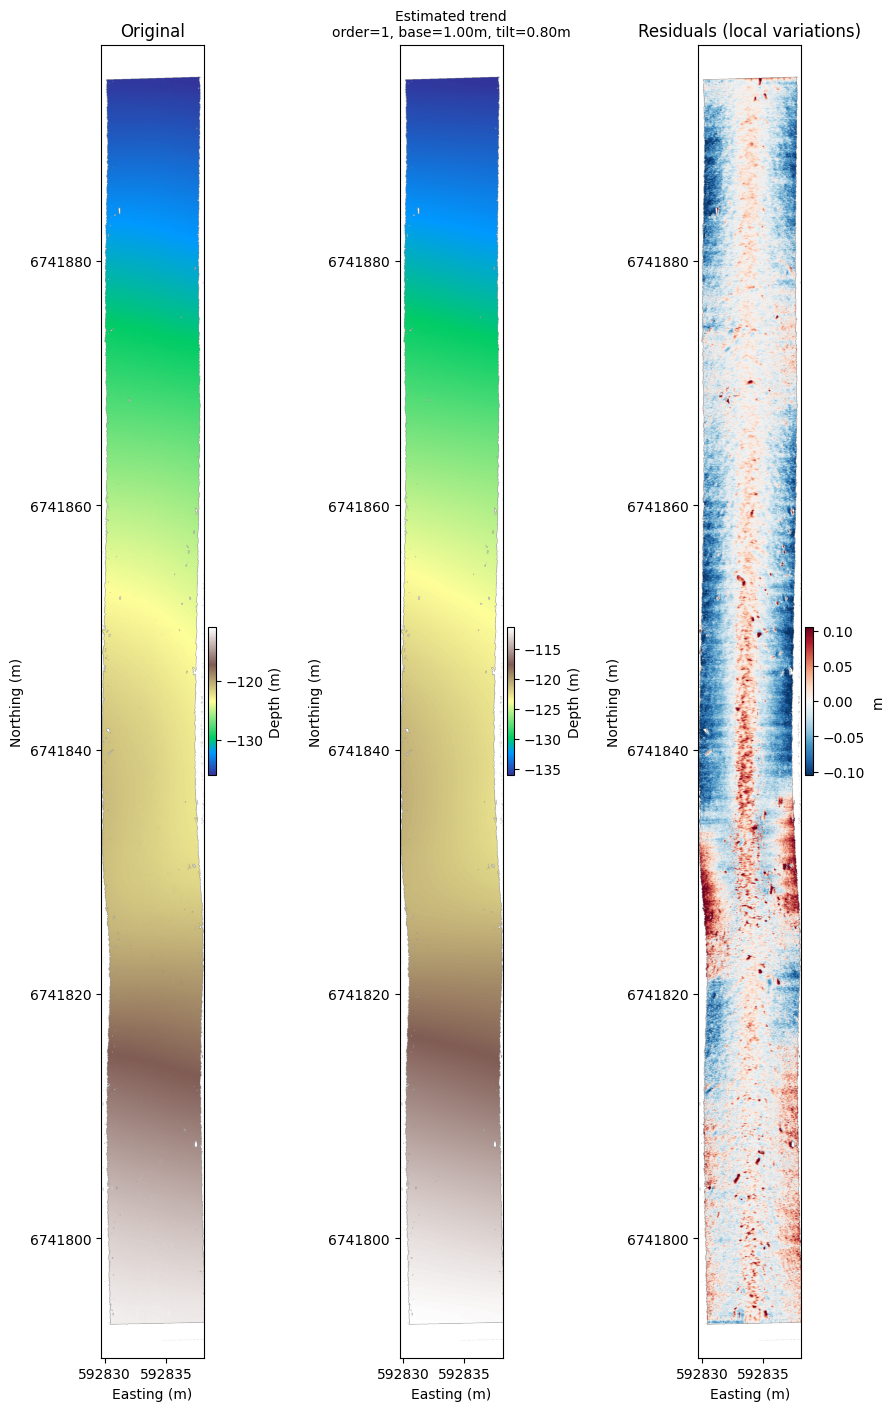

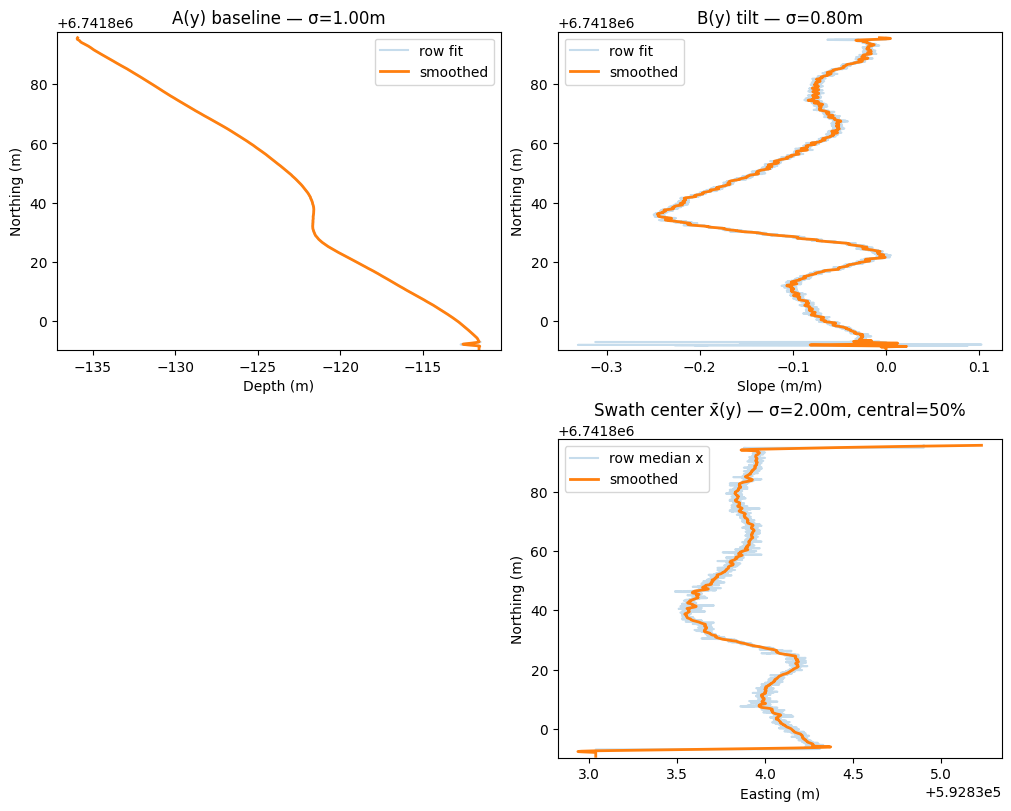

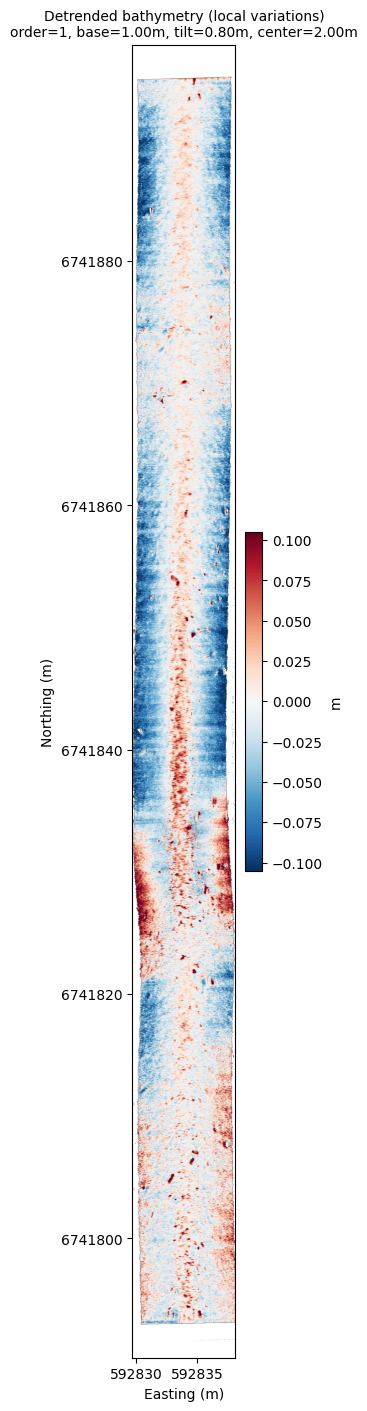

In [8]:
# ====================== mbes_autotune_quick_fixed.py =========================
# Fast autotuner for MBESDetrender that does NOT rely on any class/private helpers.
# Paste this AFTER your MBESDetrender class (same Python process), or save as a
# separate file and import. Requires: numpy, scipy, matplotlib (already in use).

import os, csv, json, time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import numpy as np
from scipy.ndimage import gaussian_filter1d

# --------- small robust helpers (self-contained) -----------------------------


def _nanmad(a):
    a = np.asarray(a, float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan
    med = np.median(a)
    return np.median(np.abs(a - med))


def _robust_std(a):
    m = _nanmad(a)
    return 1.4826 * m if np.isfinite(m) else np.nan


def _finite(a):
    return np.asarray(a, float)[np.isfinite(a)]


def _banding_metric(resid):
    # Stripe/banding: dispersion of column medians normalized by robust std
    col_med = np.nanmedian(resid, axis=0)
    num = np.nanstd(col_med)
    den = _robust_std(resid)
    return float(num / (den + 1e-9)) if np.isfinite(den) else 0.0


def _edge_bias_metric(resid, center_frac=0.6):
    # Penalize red-center / blue-edges pattern (or vice versa)
    rstd = _robust_std(resid)
    if not np.isfinite(rstd) or rstd == 0:
        return 0.0
    H, W = resid.shape
    c0 = int((1.0 - center_frac) * 0.5 * W)
    c1 = W - c0
    col_med = np.nanmedian(resid, axis=0)
    center = _finite(col_med[c0:c1])
    edge = (
        _finite(np.concatenate([col_med[:c0], col_med[c1:]]))
        if c0 > 0
        else np.array([])
    )
    if center.size == 0 or edge.size == 0:
        return 0.0
    return abs(np.nanmedian(center) - np.nanmedian(edge)) / (rstd + 1e-9)


def _roughness(v):
    v = _finite(v)
    if v.size < 3:
        return 0.0
    return float(np.nanmedian(np.abs(np.diff(v))))


def _unique_key(d: Dict) -> str:
    return json.dumps({k: d[k] for k in sorted(d)}, sort_keys=True)


# --------- smoothing helpers (independent of your class) ---------------------


def _rows_from_meters(pix_size_y, meters, poly=2):
    n = max(5, int(round((meters or 0.0) / max(abs(pix_size_y) or 1.0, 1e-9))))
    if n % 2 == 0:
        n += 1
    if n <= poly + 2:
        n = poly + 3 if (poly + 3) % 2 == 1 else poly + 4
    return n


def _sg_nanaware(arr, pix_size_y, meters, poly=2):
    """Savitzky–Golay-like smoother that copes with NaNs; falls back to Gaussian
    when the SG window would exceed #valid samples."""
    a = np.asarray(arr, float)
    valid = np.isfinite(a)
    if valid.sum() < 3:
        return a.copy()

    nwin = _rows_from_meters(pix_size_y, meters, poly=poly)
    if valid.sum() < nwin:
        # Fallback: NaN-aware Gaussian via normalization
        tmp = a.copy()
        tmp[~valid] = 0.0
        w = valid.astype(float)
        sigma = max(0.5, nwin / 6)
        num = gaussian_filter1d(tmp, sigma=sigma, mode="reflect", truncate=3.5)
        den = gaussian_filter1d(w, sigma=sigma, mode="reflect", truncate=3.5)
        out = np.where(den > 1e-6, num / den, np.nan)
        out[~valid] = np.nan
        return out

    # Prefill internal gaps with linear interpolation; then edge-interp SG
    from scipy.signal import savgol_filter

    filled = a.copy()
    if (~valid).any():
        idx = np.arange(filled.size)
        filled[~valid] = np.interp(idx[~valid], idx[valid], filled[valid])
    out = savgol_filter(filled, window_length=nwin, polyorder=poly, mode="interp")
    return out


# --------- search spaces -----------------------------------------------------


def _coarse_space(mode: str = "MEDIUM") -> List[Dict]:
    """
    LITE   :  72 combos
    MEDIUM : 162 combos (default)
    FULL   : 576 combos
    NOTE: order=3 behaves like 2 in your detrend (no cubic term); kept for completeness.
    """
    if mode.upper() == "LITE":
        orders = [1, 2]
        cfracs = [0.7, 0.9]
        bases = [0.4, 0.8, 1.6]
        tilts = [0.4, 0.8, 1.6]
        centers = [0.4, 0.8, 1.6]
    elif mode.upper() == "FULL":
        orders = [1, 2, 3]
        cfracs = [0.6, 0.8, 1.0]
        bases = [0.2, 0.4, 0.8, 1.6]
        tilts = [0.2, 0.4, 0.8, 1.6]
        centers = [0.2, 0.4, 0.8, 1.6]
    else:  # MEDIUM
        orders = [1, 2]
        cfracs = [0.6, 0.8, 1.0]
        bases = [0.4, 0.8, 1.6]
        tilts = [0.4, 0.8, 1.6]
        centers = [0.4, 0.8, 1.6]

    space = []
    for o in orders:
        for cf in cfracs:
            for b in bases:
                for t in tilts:
                    for c in centers:
                        space.append(
                            dict(
                                order=o,
                                central_frac=cf,
                                baseline_m=b,
                                tilt_m=t,
                                center_m=c,
                            )
                        )
    return space


def _neighbors(around: Dict) -> List[Dict]:
    mults = [0.6, 0.8, 1.0, 1.25, 1.6]
    orders = [max(1, min(3, around["order"] + d)) for d in (-1, 0, 1)]
    cfs = sorted(
        set(
            [
                max(0.5, min(1.0, around["central_frac"] + d))
                for d in (-0.2, -0.1, 0.0, +0.1, +0.2)
            ]
        )
    )
    out = []
    for o in orders:
        for cf in cfs:
            for mb in mults:
                for mt in mults:
                    for mc in mults:
                        out.append(
                            dict(
                                order=o,
                                central_frac=cf,
                                baseline_m=max(0.05, around["baseline_m"] * mb),
                                tilt_m=max(0.05, around["tilt_m"] * mt),
                                center_m=max(0.05, around["center_m"] * mc),
                            )
                        )
    return out


# -------- scoring weights ----------------------------------------------------


@dataclass
class ScoreWeights:
    w_rstd: float = 1.0
    w_banding: float = 1.0
    w_edge_bias: float = 2.5  # strong to kill red-center/blue-edges
    w_rough_B: float = 0.3
    w_rough_X: float = 0.3


@dataclass
class RunResult:
    params: Dict
    score: float
    diagnostics: Dict


# --------- row-fit cache (per order & central_frac) --------------------------


class _RowFitCache:
    """Cache raw per-row fits (A,B,C and x̄) for (order, central_frac) pairs."""

    def __init__(self, base: "MBESDetrender"):
        self.base = base
        self.store: Dict[
            Tuple[int, float], Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        ] = {}

    def get(self, order: int, central_frac: float, robust: bool = True):
        key = (int(order), float(np.round(central_frac, 3)))
        if key in self.store:
            return self.store[key]

        Z = self.base.data
        x = self.base.x_cols
        H, W = Z.shape
        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)
        x_center = np.full(H, np.nan)

        from scipy.stats import median_abs_deviation

        for i in range(H):
            row = Z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue
            xv = x[m]
            yv = row[m]
            xc_row = np.median(xv)
            x_center[i] = xc_row

            if 0 < central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row
            deg = 2 if order >= 2 else 1
            coef = np.polyfit(xi, yv, deg)
            if deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])

            if robust and deg > 0:
                for _ in range(3):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    XtW = X * w
                    beta = np.linalg.lstsq(XtW.T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0

            A[i], B[i], C[i] = a0, a1, a2

        self.store[key] = (A, B, C, x_center)
        return self.store[key]


# --------- fast evaluator (sub-grid + our own smoothing) ---------------------


class _FastEvaluator:
    def __init__(
        self,
        base: "MBESDetrender",
        rowfit_cache: _RowFitCache,
        row_stride: int = 4,
        col_stride: int = 4,
    ):
        self.base = base
        self.cache = rowfit_cache
        self.row_stride = max(1, int(row_stride))
        self.col_stride = max(1, int(col_stride))

    def evaluate(self, params: Dict, weights: ScoreWeights) -> RunResult:
        order = int(params["order"])
        cf = float(params["central_frac"])
        A, B, C, Xc = self.cache.get(order, cf)

        # Smooth (self-contained)
        A_s = _sg_nanaware(A, self.base.px_y, params["baseline_m"], poly=2)
        B_s = _sg_nanaware(B, self.base.px_y, params["tilt_m"], poly=2)
        curv_m = params["tilt_m"]  # same scale as tilt for C; order<2 => C≈0 anyway
        C_s = _sg_nanaware(C, self.base.px_y, curv_m, poly=2)
        Xc_s = _sg_nanaware(Xc, self.base.px_y, params["center_m"], poly=2)

        # Sub-grid residuals
        rs = slice(None, None, self.row_stride)
        cs = slice(None, None, self.col_stride)
        rows = np.arange(self.base.data.shape[0])[rs]
        cols = np.arange(self.base.data.shape[1])[cs]
        Z = self.base.data[np.ix_(rows, cols)]
        VM = (
            self.base.valid_mask[np.ix_(rows, cols)]
            if self.base.valid_mask is not None
            else np.isfinite(Z)
        )

        xi = self.base.x_cols[cols][None, :] - Xc_s[rows][:, None]
        trend = A_s[rows, None] + B_s[rows, None] * xi + C_s[rows, None] * (xi**2)
        resid = Z - trend
        resid[~VM] = np.nan

        # Score
        rstd = _robust_std(resid)
        banding = _banding_metric(resid)
        edge_bias = _edge_bias_metric(resid, center_frac=0.6)
        rough_B = _roughness(B_s)
        rough_X = _roughness(Xc_s)
        score = (
            weights.w_rstd * rstd
            + weights.w_banding * banding
            + weights.w_edge_bias * edge_bias
            + weights.w_rough_B * rough_B
            + weights.w_rough_X * rough_X
        )
        diags = dict(
            rstd=rstd,
            banding=banding,
            edge_bias=edge_bias,
            rough_B=rough_B,
            rough_X=rough_X,
        )
        return RunResult(params=params, score=float(score), diagnostics=diags)


# --------- main tuner --------------------------------------------------------


class AutoTuneMBES:
    """
    Extremely fast tuner:
      - No repeated GeoTIFF I/O (reuse arrays from your loaded MBESDetrender)
      - Caches per-row fits (A,B,C,x̄) for (order, central_frac)
      - Sub-sampled scoring (row_stride, col_stride)
      - Coarse grid + local refinement
    """

    def __init__(
        self,
        mbes: "MBESDetrender",
        weights: ScoreWeights = ScoreWeights(),
        log_csv: str = "mbes_tuning_log.csv",
        row_stride: int = 4,
        col_stride: int = 4,
        progress_every: int = 5,
    ):
        assert mbes.data is not None, "Call .load() on MBESDetrender first."
        self.base = mbes
        self.weights = weights
        self.log_csv = log_csv
        self.progress_every = max(1, int(progress_every))
        self.tried: Dict[str, Tuple[float, Dict, Dict]] = {}
        self.best_params: Optional[Dict] = None
        self.best_score: float = float("inf")
        self.cache = _RowFitCache(self.base)
        self.eval_fast = _FastEvaluator(
            self.base, self.cache, row_stride=row_stride, col_stride=col_stride
        )

    # CSV logging
    def _write_row(self, p: Dict, res: RunResult):
        header = [
            "order",
            "central_frac",
            "baseline_m",
            "tilt_m",
            "center_m",
            "score",
            "rstd",
            "banding",
            "edge_bias",
            "rough_B",
            "rough_X",
        ]
        exists = os.path.exists(self.log_csv)
        with open(self.log_csv, "a", newline="") as f:
            w = csv.writer(f)
            if not exists:
                w.writerow(header)
            d = res.diagnostics
            w.writerow(
                [
                    p["order"],
                    p["central_frac"],
                    p["baseline_m"],
                    p["tilt_m"],
                    p["center_m"],
                    res.score,
                    d.get("rstd"),
                    d.get("banding"),
                    d.get("edge_bias"),
                    d.get("rough_B"),
                    d.get("rough_X"),
                ]
            )

    def _load_tried(self):
        if not os.path.exists(self.log_csv):
            return
        with open(self.log_csv, "r", newline="") as f:
            r = csv.DictReader(f)
            for row in r:
                p = dict(
                    order=int(float(row["order"])),
                    central_frac=float(row["central_frac"]),
                    baseline_m=float(row["baseline_m"]),
                    tilt_m=float(row["tilt_m"]),
                    center_m=float(row["center_m"]),
                )
                key = _unique_key(p)
                sc = float(row["score"])
                self.tried[key] = (sc, p, {})
                if sc < self.best_score:
                    self.best_score, self.best_params = sc, p

    def _run_once(self, p: Dict) -> RunResult:
        return self.eval_fast.evaluate(p, self.weights)

    def fit(
        self, max_rounds: int = 2, coarse_mode: str = "MEDIUM", resume: bool = True
    ) -> Dict:
        if resume:
            self._load_tried()

        space = _coarse_space(coarse_mode)
        total = len(space)
        print(
            f"▶ Coarse search: {total} combos ({coarse_mode}). Already tried: {len(self.tried)}",
            flush=True,
        )

        start = time.time()
        done = 0
        for p in space:
            key = _unique_key(p)
            if key in self.tried:
                continue
            res = self._run_once(p)
            self.tried[key] = (res.score, p, res.diagnostics)
            self._write_row(p, res)
            done += 1

            if res.score < self.best_score:
                self.best_score = res.score
                self.best_params = p

            if done % self.progress_every == 0 or done == 1:
                elapsed = time.time() - start
                rate = done / max(elapsed, 1e-6)
                eta = (total - done) / max(rate, 1e-6)
                print(
                    f"  [{done}/{total}] best={self.best_score:.6f}  "
                    f"last={res.score:.6f}  ETA≈{eta/60:.1f} min",
                    flush=True,
                )

        print(
            f"🔎 Coarse best: {self.best_params} → score={self.best_score:.6f}",
            flush=True,
        )

        # Local refinement around current best
        for r in range(max_rounds):
            nbrs = _neighbors(self.best_params)
            print(f"▶ Round {r+1}: {len(nbrs)} neighbors", flush=True)
            improved = False
            start = time.time()
            for i, p in enumerate(nbrs, 1):
                key = _unique_key(p)
                if key in self.tried:
                    continue
                res = self._run_once(p)
                self.tried[key] = (res.score, p, res.diagnostics)
                self._write_row(p, res)
                if res.score < self.best_score - 1e-9:
                    self.best_score = res.score
                    self.best_params = p
                    improved = True
                if i % self.progress_every == 0 or i == 1:
                    elapsed = time.time() - start
                    rate = i / max(elapsed, 1e-6)
                    eta = (len(nbrs) - i) / max(rate, 1e-6)
                    print(
                        f"  [{i}/{len(nbrs)}] best={self.best_score:.6f} "
                        f"last={res.score:.6f}  ETA≈{eta/60:.1f} min",
                        flush=True,
                    )
            if not improved:
                print(f"⏹️  Stop after round {r+1}: no improvement.", flush=True)
                break

        print(
            f"🏁 Best params: {self.best_params}  score={self.best_score:.6f}",
            flush=True,
        )
        return self.best_params

    def apply_best_and_plot(self):
        assert self.best_params is not None, "Run .fit() first."
        p = self.best_params
        # Full-quality run for plotting on the full grid
        mb = MBESDetrender(self.base.tif_path).load()
        mb.detrend(
            order_x=p["order"],
            smooth_baseline_m=p["baseline_m"],
            smooth_tilt_m=p["tilt_m"],
            smooth_center_m=p["center_m"],
            robust=True,
            central_frac=p["central_frac"],
        )
        print("📈 Plotting with best params...", flush=True)
        mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
        mb.plot_components(figsize=(10, 8))
        mb.plot_residual_heatmap(figsize=(6, 14), equal_aspect=True)
        return mb


# --------------------------- example / CLI -----------------------------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    plt.ion()

    # Change this path if needed:
    tif = r"E:\mjosa_new\DTM\geotiff_2.tif"
    base = MBESDetrender(tif).load()

    # FAST: score on ~1/16th of pixels; increase strides for even faster,
    # or set to (1,1) for max fidelity during refinement.
    tuner = AutoTuneMBES(
        base,
        weights=ScoreWeights(
            w_rstd=1.0, w_banding=1.0, w_edge_bias=2.5, w_rough_B=0.3, w_rough_X=0.3
        ),
        row_stride=4,
        col_stride=4,
        progress_every=3,
    )

    # Use "LITE" for the quickest coarse pass; "MEDIUM" or "FULL" if you have time.
    best = tuner.fit(max_rounds=2, coarse_mode="LITE", resume=True)
    mb_best = tuner.apply_best_and_plot()
    plt.show(block=True)
# ============================================================================

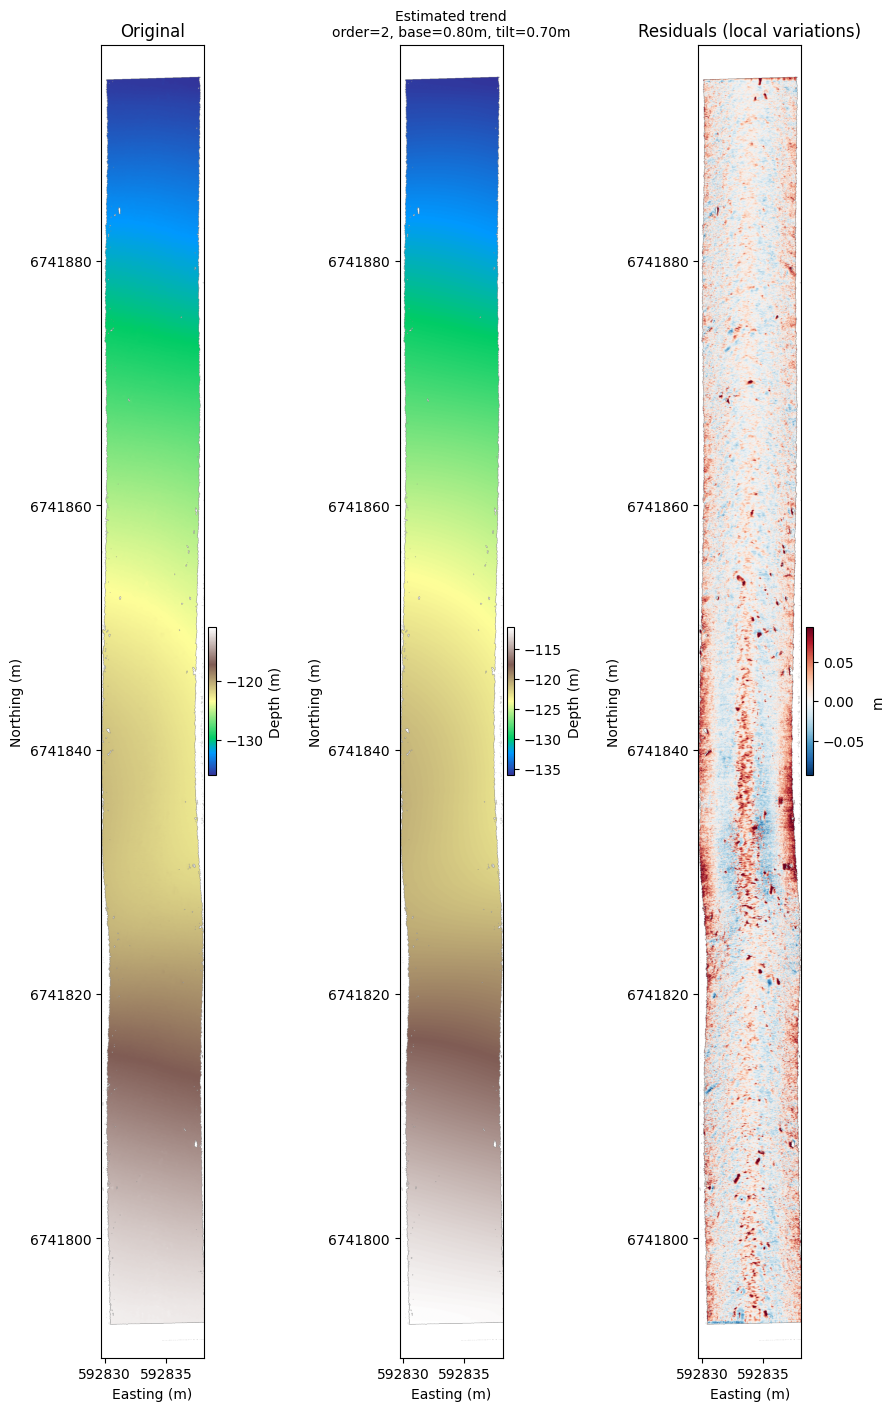

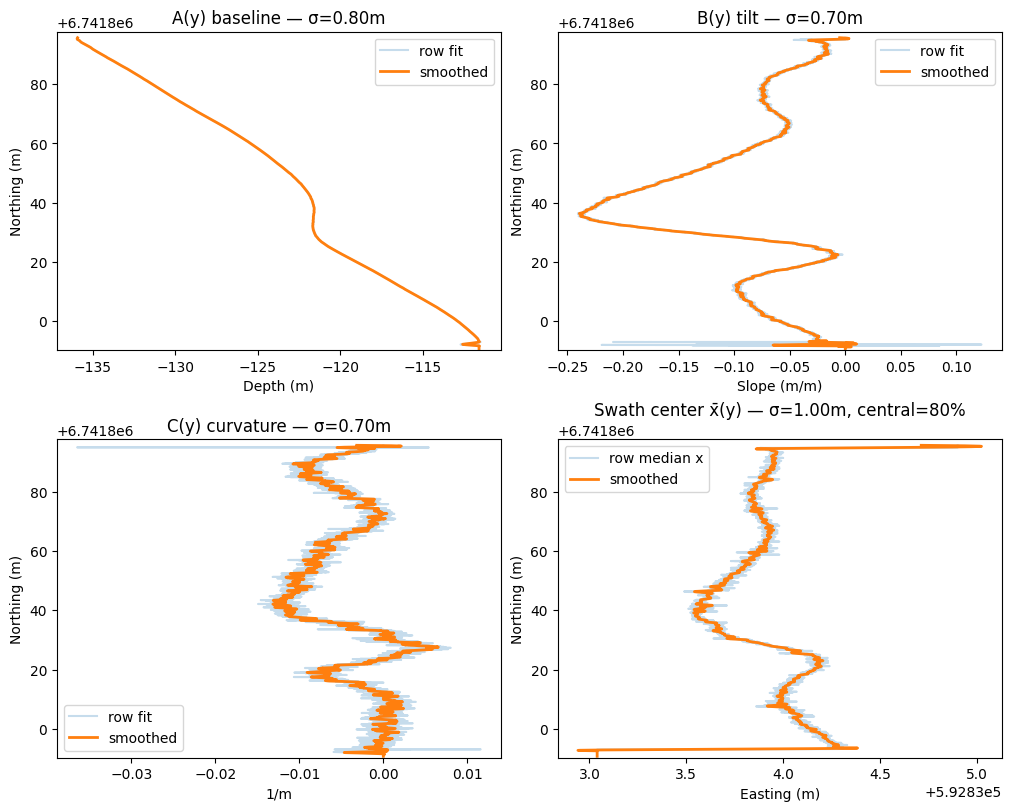

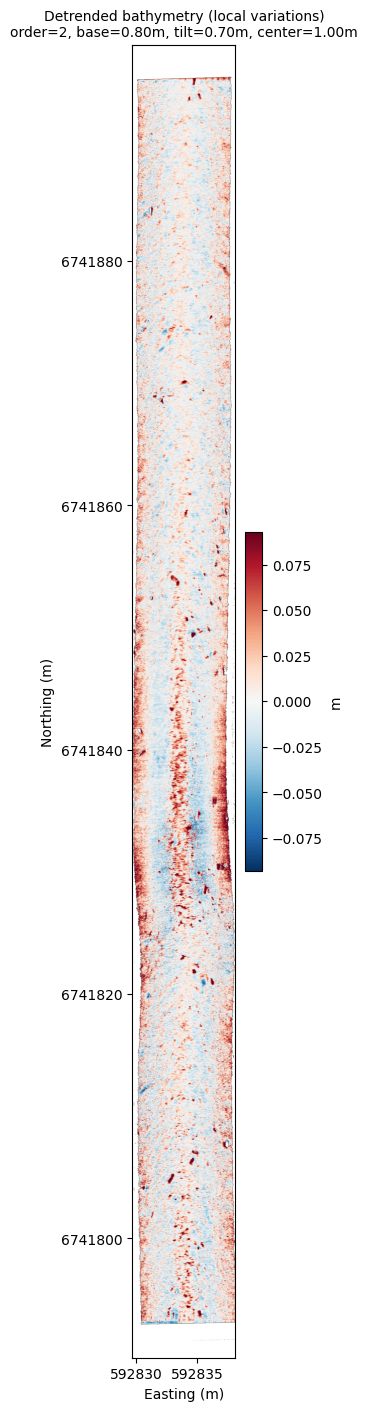

In [9]:
# mbes_detrend_plot_fixed.py
# Standalone: pip install rasterio numpy matplotlib scipy

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.stats import median_abs_deviation


# ---------- helpers -----------------------------------------------------------


def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    """Pad axes limits a bit and set a data-driven aspect so tall/skinny swaths
    fill the figure instead of being squashed into a sliver."""
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)

    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)

    if equal_aspect:
        # Keep meters equal AND resize the axes box to the data ratio.
        # (Prevents the “half a figure” look with very tall/skinny rasters.)
        ax.set_aspect("equal", adjustable="datalim")
        try:
            ax.set_box_aspect(yr / xr)  # Matplotlib ≥ 3.3
        except Exception:
            pass

    # Plain numeric ticks (no +6.74e6 offsets)
    try:
        ax.ticklabel_format(style="plain", axis="both", useOffset=False)
    except Exception:
        pass


def _robust_sym_vlim(arr, q=0.98):
    m = np.isfinite(arr)
    if not m.any():
        return (-1, 1)
    lo, hi = np.nanquantile(arr[m], [(1 - q) / 2, 1 - (1 - q) / 2])
    vmax = max(abs(lo), abs(hi))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = (np.nanstd(arr[m]) or 1.0) * 3
    return (-vmax, vmax)


def _rows_from_meters(pix_size_y, meters, poly=2):
    n = max(5, int(round((meters or 0.0) / max(abs(pix_size_y) or 1.0, 1e-9))))
    if n % 2 == 0:
        n += 1
    if n <= poly + 2:
        n = poly + 3 if (poly + 3) % 2 == 1 else poly + 4
    return n


def _savgol_nanaware(arr, pix_size_y, meters, poly=2):
    """Savitzky–Golay smoothing that copes with NaNs; falls back to Gaussian if
    window > #valid samples."""
    a = np.asarray(arr, float)
    valid = np.isfinite(a)
    if valid.sum() < 3:
        return a.copy()

    nwin = _rows_from_meters(pix_size_y, meters, poly=poly)

    if valid.sum() < nwin:
        # Fallback: NaN-aware Gaussian via normalization
        tmp = a.copy()
        tmp[~valid] = 0.0
        w = valid.astype(float)
        sigma = max(0.5, nwin / 6)
        num = gaussian_filter1d(tmp, sigma=sigma, mode="reflect", truncate=3.5)
        den = gaussian_filter1d(w, sigma=sigma, mode="reflect", truncate=3.5)
        out = np.where(den > 1e-6, num / den, np.nan)
        out[~valid] = np.nan
        return out

    # Prefill internal gaps with linear interpolation, then SG with edge interp
    filled = a.copy()
    if (~valid).any():
        idx = np.arange(filled.size)
        filled[~valid] = np.interp(idx[~valid], idx[valid], filled[valid])
    out = savgol_filter(filled, window_length=nwin, polyorder=poly, mode="interp")
    return out


# ---------- main class --------------------------------------------------------


@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0

    # smoothing scales (meters, along-track)
    smooth_baseline_m: float = 10.0  # A(y)
    smooth_tilt_m: float = 20.0  # B(y)
    smooth_curv_m: Optional[float] = None  # C(y); defaults to tilt_m
    smooth_center_m: float = 6.0  # x̄(y)

    # robust fit options
    max_row_iters: int = 3
    clip_sigma: float = 6.0
    central_frac: float = 0.8  # use central 80% of beams

    # internals (filled by load/detrend)
    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None

    A: Optional[np.ndarray] = None
    B: Optional[np.ndarray] = None
    C: Optional[np.ndarray] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    x_center_row: Optional[np.ndarray] = None
    x_center_s: Optional[np.ndarray] = None

    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    # --- I/O ---
    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            b = src.bounds

        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.valid_mask = np.isfinite(z)
        self.data = z
        self.transform = tf
        self.extent = (float(b.left), float(b.right), float(b.bottom), float(b.top))

        a, _, c, _, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        return self

    # --- detrend ---
    def detrend(
        self,
        order_x: int = 2,  # 0: baseline, 1: +tilt, 2: +curvature
        remove_cross_track_tilt: bool = True,
        robust: bool = True,
        smooth_baseline_m: Optional[float] = None,
        smooth_tilt_m: Optional[float] = None,
        smooth_curv_m: Optional[float] = None,
        smooth_center_m: Optional[float] = None,
        central_frac: Optional[float] = None,
    ):
        if self.data is None:
            self.load()

        if smooth_baseline_m is not None:
            self.smooth_baseline_m = float(smooth_baseline_m)
        if smooth_tilt_m is not None:
            self.smooth_tilt_m = float(smooth_tilt_m)
        if smooth_curv_m is not None:
            self.smooth_curv_m = float(smooth_curv_m)
        if smooth_center_m is not None:
            self.smooth_center_m = float(smooth_center_m)
        if central_frac is not None:
            self.central_frac = float(central_frac)
        if self.smooth_curv_m is None:
            self.smooth_curv_m = self.smooth_tilt_m

        Z = self.data
        x = self.x_cols
        H, W = Z.shape

        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)
        x_center = np.full(H, np.nan)

        # per-row robust polynomial around each row's center
        for i in range(H):
            row = Z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue

            xv = x[m]
            yv = row[m]

            xc_row = np.median(xv)
            x_center[i] = xc_row

            if 0 < self.central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * self.central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * self.central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row
            deg = (
                2
                if (order_x >= 2 and remove_cross_track_tilt)
                else (1 if remove_cross_track_tilt else 0)
            )
            coef = np.polyfit(xi, yv, deg)

            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])

            if robust and deg > 0:
                for _ in range(self.max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)

                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    XtW = X * w
                    beta = np.linalg.lstsq(XtW.T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])

            A[i] = a0
            B[i] = a1 if remove_cross_track_tilt else 0.0
            C[i] = a2 if (order_x >= 2 and remove_cross_track_tilt) else 0.0

        # clip crazy rows, fill short gaps
        def _clip_and_fill(arr):
            s = arr.copy()
            m = np.isfinite(s)
            if m.sum() < 5:
                return s
            med = np.nanmedian(s[m])
            mad = median_abs_deviation(s[m], scale="normal") or np.nanstd(s[m])
            if np.isfinite(mad) and mad > 0:
                lo, hi = med - self.clip_sigma * mad, med + self.clip_sigma * mad
                s[(s < lo) | (s > hi)] = np.nan
            idx = np.arange(len(s))
            good = np.isfinite(s)
            if good.sum() >= 2:
                s[~good] = np.interp(idx[~good], idx[good], s[good])
            return s

        A = _clip_and_fill(A)
        B = _clip_and_fill(B)
        C = _clip_and_fill(C)
        x_center = _clip_and_fill(x_center)

        # along-track smoothing (edge safe)
        A_s = _savgol_nanaware(A, self.px_y, self.smooth_baseline_m, poly=2)
        B_s = _savgol_nanaware(B, self.px_y, self.smooth_tilt_m, poly=2)
        C_s = _savgol_nanaware(C, self.px_y, self.smooth_curv_m, poly=2)
        Xc = _savgol_nanaware(x_center, self.px_y, self.smooth_center_m, poly=2)

        # reconstruct trend & residuals
        xi_grid = self.x_cols[None, :] - Xc[:, None]
        trend = A_s[:, None] + B_s[:, None] * xi_grid + C_s[:, None] * (xi_grid**2)
        if self.valid_mask is not None:
            trend = np.where(self.valid_mask, trend, np.nan)

        resid = self.data - trend
        resid[~np.isfinite(self.data)] = np.nan

        # store
        self.A, self.B, self.C = A, B, C
        self.A_s, self.B_s, self.C_s = A_s, B_s, C_s
        self.x_center_row, self.x_center_s = x_center, Xc
        self.trend, self.residuals = trend, resid
        return self

    # --- plotting ---
    def _extent(self):
        return (self.extent[0], self.extent[1], self.extent[2], self.extent[3])

    def _data_window(self, percentile=99.5):
        rows, cols = np.where(np.isfinite(self.data))
        if rows.size == 0:
            return self._extent()
        p_lo = (100 - percentile) / 2
        p_hi = 100 - p_lo
        c0 = int(np.percentile(cols, p_lo))
        c1 = int(np.percentile(cols, p_hi))
        r0 = int(np.percentile(rows, p_lo))
        r1 = int(np.percentile(rows, p_hi))
        x_min, x_max = self.x_cols[c0], self.x_cols[c1]
        y_min, y_max = self.y_rows[r1], self.y_rows[r0]
        return (x_min, x_max, y_min, y_max)

    def plot_triptych(
        self,
        cmap_orig="terrain",
        cmap_resid="RdBu_r",
        figsize=(9, 14),  # tall default for skinny swaths
        crop_to_data=True,
        bounds_percentile=99.5,
        margin_frac=0.03,
        equal_aspect=True,
    ):
        assert self.trend is not None, "Run detrend() first."
        fig, axs = plt.subplots(
            1, 3, figsize=figsize, constrained_layout=True, num="MBES Triptych"
        )

        im0 = axs[0].imshow(
            np.ma.masked_invalid(self.data),
            extent=self._extent(),
            origin="upper",
            cmap=cmap_orig,
        )
        axs[0].set_title("Original")
        axs[0].set_xlabel("Easting (m)")
        axs[0].set_ylabel("Northing (m)")
        fig.colorbar(im0, ax=axs[0], label="Depth (m)", fraction=0.035, pad=0.02)

        im1 = axs[1].imshow(
            np.ma.masked_invalid(self.trend),
            extent=self._extent(),
            origin="upper",
            cmap=cmap_orig,
        )
        ord_label = (
            2 if (self.C_s is not None and np.nanmax(np.abs(self.C_s)) > 0.001) else 1
        )
        axs[1].set_title(
            f"Estimated trend\norder={ord_label}, base={self.smooth_baseline_m:.2f}m, tilt={self.smooth_tilt_m:.2f}m",
            fontsize=10,
        )
        axs[1].set_xlabel("Easting (m)")
        axs[1].set_ylabel("Northing (m)")
        fig.colorbar(im1, ax=axs[1], label="Depth (m)", fraction=0.035, pad=0.02)

        vmin, vmax = _robust_sym_vlim(self.residuals, q=0.98)
        im2 = axs[2].imshow(
            np.ma.masked_invalid(self.residuals),
            extent=self._extent(),
            origin="upper",
            cmap=cmap_resid,
            vmin=vmin,
            vmax=vmax,
        )
        axs[2].set_title("Residuals (local variations)")
        axs[2].set_xlabel("Easting (m)")
        axs[2].set_ylabel("Northing (m)")
        fig.colorbar(im2, ax=axs[2], label="m", fraction=0.035, pad=0.02)

        if crop_to_data:
            x_min, x_max, y_min, y_max = self._data_window(bounds_percentile)
        else:
            x_min, x_max, y_min, y_max = self._extent()

        for ax in axs:
            _pad_limits(
                ax,
                x_min,
                x_max,
                y_min,
                y_max,
                pad_frac=margin_frac,
                equal_aspect=equal_aspect,
            )

        plt.show(block=False)
        return fig

    def plot_residual_heatmap(
        self,
        figsize=(6, 14),
        cmap="RdBu_r",
        vmax=None,
        crop_to_data=True,
        bounds_percentile=99.5,
        margin_frac=0.03,
        equal_aspect=True,
        title_suffix="",
    ):
        assert self.residuals is not None, "Run detrend() first."
        if vmax is None:
            vmin, vmax = _robust_sym_vlim(self.residuals, q=0.98)
        else:
            vmin, vmax = -abs(vmax), abs(vmax)

        fig, ax = plt.subplots(
            1, 1, figsize=figsize, constrained_layout=True, num="MBES Residuals"
        )
        im = ax.imshow(
            np.ma.masked_invalid(self.residuals),
            extent=self._extent(),
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        if crop_to_data:
            x_min, x_max, y_min, y_max = self._data_window(bounds_percentile)
        else:
            x_min, x_max, y_min, y_max = self._extent()

        _pad_limits(
            ax,
            x_min,
            x_max,
            y_min,
            y_max,
            pad_frac=margin_frac,
            equal_aspect=equal_aspect,
        )

        ord_label = (
            2 if (self.C_s is not None and np.nanmax(np.abs(self.C_s)) > 0.001) else 1
        )
        settings = f"order={ord_label}, base={self.smooth_baseline_m:.2f}m, tilt={self.smooth_tilt_m:.2f}m, center={self.smooth_center_m:.2f}m"
        ax.set_title(
            f"Detrended bathymetry (local variations)\n{settings}{(' — ' + title_suffix) if title_suffix else ''}",
            fontsize=10,
        )
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        fig.colorbar(im, ax=ax, label="m", fraction=0.035, pad=0.02)
        plt.show(block=False)
        return fig

    def plot_components(
        self, figsize=(10, 8), bounds_percentile=99.5, margin_frac=0.03
    ):
        assert self.A_s is not None, "Run detrend() first."
        y = self.y_rows
        fig, ax = plt.subplots(
            2, 2, figsize=figsize, constrained_layout=True, num="MBES Components"
        )

        ax[0, 0].plot(self.A, y, alpha=0.25, label="row fit")
        ax[0, 0].plot(self.A_s, y, lw=2, label="smoothed")
        ax[0, 0].invert_yaxis()
        ax[0, 0].set_title(f"A(y) baseline — σ={self.smooth_baseline_m:.2f}m")
        ax[0, 0].set_xlabel("Depth (m)")
        ax[0, 0].set_ylabel("Northing (m)")
        ax[0, 0].legend()

        ax[0, 1].plot(self.B, y, alpha=0.25, label="row fit")
        ax[0, 1].plot(self.B_s, y, lw=2, label="smoothed")
        ax[0, 1].invert_yaxis()
        ax[0, 1].set_title(f"B(y) tilt — σ={self.smooth_tilt_m:.2f}m")
        ax[0, 1].set_xlabel("Slope (m/m)")
        ax[0, 1].set_ylabel("Northing (m)")
        ax[0, 1].legend()

        if self.C_s is not None and np.nanmax(np.abs(self.C_s)) > 0:
            ax[1, 0].plot(self.C, y, alpha=0.25, label="row fit")
            ax[1, 0].plot(self.C_s, y, lw=2, label="smoothed")
            ax[1, 0].invert_yaxis()
            ax[1, 0].set_title(f"C(y) curvature — σ={self.smooth_curv_m:.2f}m")
            ax[1, 0].set_xlabel("1/m")
            ax[1, 0].set_ylabel("Northing (m)")
            ax[1, 0].legend()
        else:
            ax[1, 0].axis("off")

        ax[1, 1].plot(self.x_center_row, y, alpha=0.25, label="row median x")
        ax[1, 1].plot(self.x_center_s, y, lw=2, label="smoothed")
        ax[1, 1].invert_yaxis()
        ax[1, 1].set_title(
            f"Swath center x̄(y) — σ={self.smooth_center_m:.2f}m, central={self.central_frac*100:.0f}%"
        )
        ax[1, 1].set_xlabel("Easting (m)")
        ax[1, 1].set_ylabel("Northing (m)")
        ax[1, 1].legend()

        # keep y range similar to map panels
        x_min, x_max, y_min, y_max = self._data_window(bounds_percentile)
        for a in ax.flat:
            a.set_ylim(
                y_min - (y_max - y_min) * margin_frac,
                y_max + (y_max - y_min) * margin_frac,
            )

        plt.show(block=False)
        return fig


# ---------- example usage -----------------------------------------------------
if __name__ == "__main__":
    plt.ion()

    tif = r"E:\mjosa_new\DTM\geotiff_2.tif"  # <-- change if needed
    mb = MBESDetrender(tif).load()

    mb.detrend(
        order_x=3,
        smooth_baseline_m=0.80,
        smooth_tilt_m=0.70,
        smooth_center_m=1.0,
        robust=True,
        central_frac=0.8,
    )

    # Tall defaults + data-driven box aspect prevent the “half figure” look
    mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
    mb.plot_components(figsize=(10, 8))
    mb.plot_residual_heatmap(figsize=(6, 14), equal_aspect=True)

    plt.show(block=True)

c:\conda_envs\my_env\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


… tried 5/162 in coarse grid (last score 32.0707)
… tried 10/162 in coarse grid (last score 39.7945)
… tried 20/162 in coarse grid (last score 40.1594)
… tried 25/162 in coarse grid (last score 27.1940)
… tried 35/162 in coarse grid (last score 26.0538)
… tried 40/162 in coarse grid (last score 31.3530)
… tried 45/162 in coarse grid (last score 25.3800)
… tried 50/162 in coarse grid (last score 30.5039)
… tried 55/162 in coarse grid (last score 38.5882)
… tried 65/162 in coarse grid (last score 38.4264)
… tried 70/162 in coarse grid (last score 23.3780)
… tried 75/162 in coarse grid (last score 39.0811)
… tried 80/162 in coarse grid (last score 23.6596)
… tried 85/162 in coarse grid (last score 21.0248)
… tried 90/162 in coarse grid (last score 16.0091)
… tried 95/162 in coarse grid (last score 20.4384)
… tried 100/162 in coarse grid (last score 29.1043)
… tried 105/162 in coarse grid (last score 19.7382)
… tried 110/162 in coarse grid (last score 14.4201)
… tried 115/162 in coarse gri

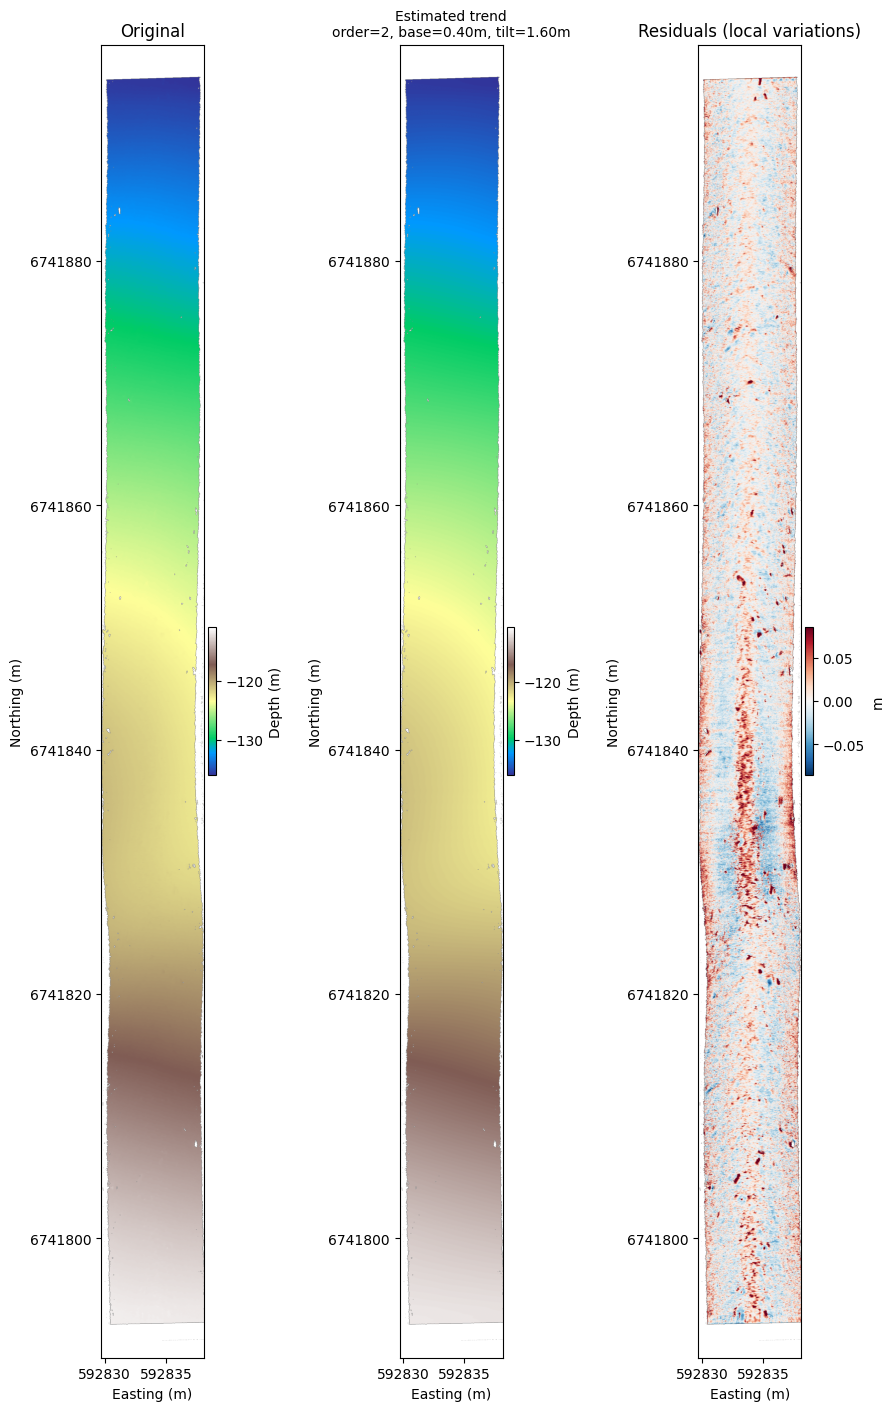

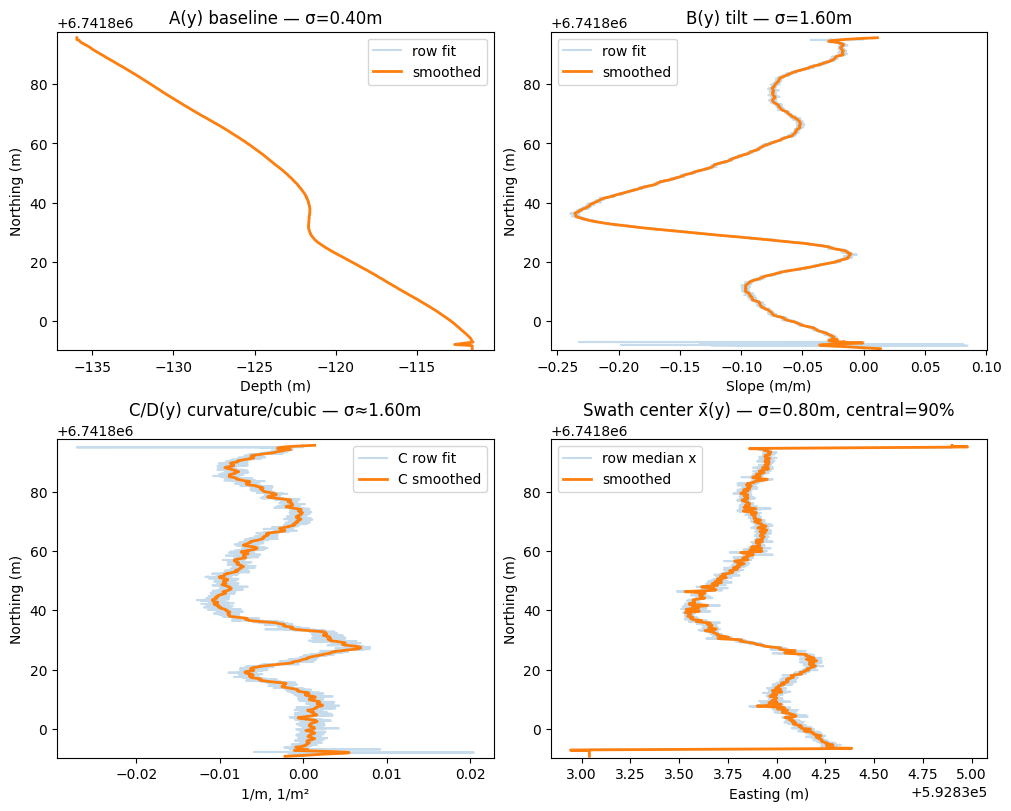

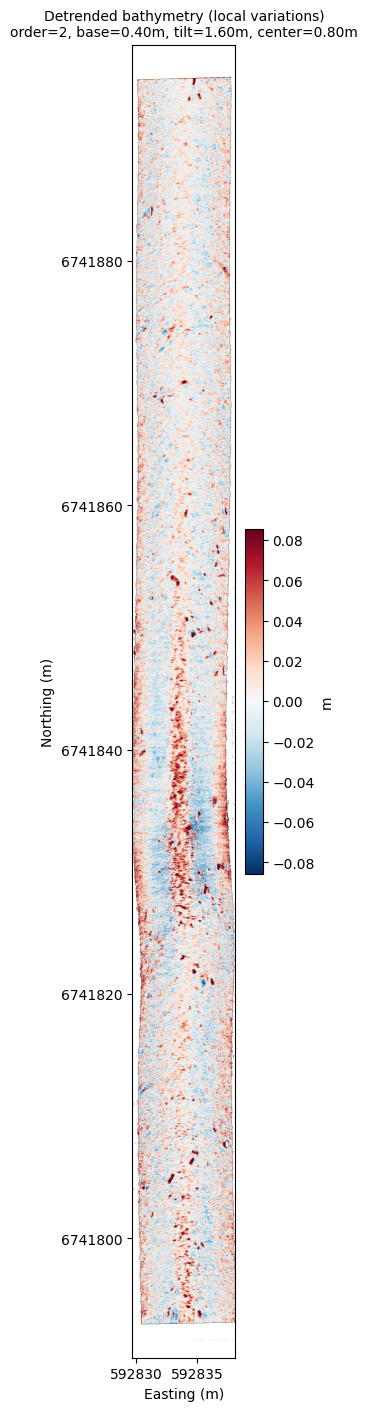

In [ ]:
# ====================== mbes_autotune_fast.py (drop-in) ======================
# Works with your existing MBESDetrender class.
# Focused, fast search (orders 2 & 3 only) + strong edge-bias penalty.
# All trials are appended to CSV so you can stop/restart freely.

import os, csv, json, time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import numpy as np


# --------------------------- robust helpers ----------------------------------


def _finite(a):
    a = np.asarray(a, float)
    return a[np.isfinite(a)]


def _nanmad(a):
    a = _finite(a)
    if a.size == 0:
        return np.nan
    m = np.median(a)
    return np.median(np.abs(a - m))


def _robust_std(a):
    mad = _nanmad(a)
    return 1.4826 * mad if np.isfinite(mad) else np.nan


def _banding_metric(resid):
    """Stripe/banding: std of column medians normalized by robust std."""
    col_med = np.nanmedian(resid, axis=0)
    num = np.nanstd(col_med)
    den = _robust_std(resid)
    return float(num / (den + 1e-12)) if np.isfinite(den) else 0.0


def _edge_bias_metric(resid, center_frac=0.6):
    """
    Penalize red-center / blue-edge.
    |median(center) - median(edges)| normalized by robust std.
    """
    rstd = _robust_std(resid)
    if not np.isfinite(rstd) or rstd == 0:
        return 0.0
    W = resid.shape[1]
    c0 = int((1.0 - center_frac) * 0.5 * W)
    c1 = W - c0
    col_med = np.nanmedian(resid, axis=0)
    center = _finite(col_med[c0:c1])
    edges = _finite(np.r_[col_med[:c0], col_med[c1:]]) if c0 > 0 else np.array([])
    if center.size == 0 or edges.size == 0:
        return 0.0
    return float(abs(np.nanmedian(center) - np.nanmedian(edges)) / (rstd + 1e-12))


def _x_slope_metric(resid):
    """
    Penalize a residual trend left->right (linear slope of column medians).
    Unitless: slope normalized by robust std per column index.
    """
    col_med = np.nanmedian(resid, axis=0)
    x = np.arange(col_med.size)
    m = np.isfinite(col_med)
    if m.sum() < 5:
        return 0.0
    # simple robust-ish slope via least squares on medians
    x0 = x[m] - x[m].mean()
    y0 = col_med[m] - np.nanmedian(col_med[m])
    slope = np.sum(x0 * y0) / (np.sum(x0 * x0) + 1e-12)
    return float(abs(slope) / (_robust_std(resid) + 1e-12))


def _roughness_1d(v):
    """Median |first-difference| for smoothness of B(y) and center x̄(y)."""
    v = _finite(v)
    if v.size < 3:
        return 0.0
    return float(np.nanmedian(np.abs(np.diff(v))))


# ------------------------------- scoring -------------------------------------


@dataclass
class ScoreWeights:
    # All terms: lower is better
    w_rstd: float = 1.0  # robust residual std
    w_banding: float = 1.0  # column-to-column striping
    w_edge_bias: float = 3.0  # center vs edges bias (kill blue sides/red center)
    w_x_slope: float = 1.0  # left->right residual tilt
    w_rough_B: float = 0.3  # smoothness of B(y)
    w_rough_X: float = 0.3  # smoothness of x̄(y)


@dataclass
class RunResult:
    params: Dict
    score: float
    diagnostics: Dict


def _score_run(mb, weights: ScoreWeights, row_stride=1, col_stride=1) -> RunResult:
    """
    Compute the score on a subsampled residual grid for speed.
    """
    resid = mb.residuals
    assert resid is not None
    rs = resid[:: max(1, row_stride), :: max(1, col_stride)]

    rstd = _robust_std(rs)
    band = _banding_metric(rs)
    edge = _edge_bias_metric(rs, center_frac=0.6)
    xs = _x_slope_metric(rs)

    # smoothness of trends (avoid chasing rigid beam lines)
    rough_B = _roughness_1d(getattr(mb, "B_s", np.array([])))
    rough_X = _roughness_1d(getattr(mb, "x_center_s", np.array([])))

    score = (
        weights.w_rstd * (rstd if np.isfinite(rstd) else 0.0)
        + weights.w_banding * band
        + weights.w_edge_bias * edge
        + weights.w_x_slope * xs
        + weights.w_rough_B * rough_B
        + weights.w_rough_X * rough_X
    )
    diags = dict(
        rstd=rstd,
        banding=band,
        edge_bias=edge,
        x_slope=xs,
        rough_B=rough_B,
        rough_X=rough_X,
    )
    return RunResult(params={}, score=float(score), diagnostics=diags)


# --------------------------- search space ------------------------------------


def _unique_key(d: Dict) -> str:
    return json.dumps({k: d[k] for k in sorted(d)}, sort_keys=True)


def _coarse_space(allowed_orders=(2, 3)) -> List[Dict]:
    """
    Small, sane grid. All in meters along-track.
      baseline_m ~ A(y) smoother
      tilt_m     ~ B(y) smoother
      center_m   ~ x̄(y) smoother
    """
    space = []
    for order in allowed_orders:
        for cf in [0.7, 0.8, 0.9]:
            for base in [0.4, 0.8, 1.2]:
                for tilt in [0.4, 0.8, 1.2]:
                    for center in [0.6, 1.0, 1.6]:
                        space.append(
                            dict(
                                order=order,
                                central_frac=cf,
                                baseline_m=base,
                                tilt_m=tilt,
                                center_m=center,
                            )
                        )
    return space


def _neighbors(best: Dict) -> List[Dict]:
    """
    Local refinement around best (multiplicative tweaks).
    """
    mults = [0.7, 0.85, 1.0, 1.2, 1.5]
    cfs = [
        max(0.6, min(0.95, best["central_frac"] + d))
        for d in (-0.1, -0.05, 0.0, 0.05, 0.1)
    ]
    orders = [best["order"]]  # keep chosen order during refinement
    out = []
    for o in orders:
        for cf in cfs:
            for mb in mults:
                for mt in mults:
                    for mc in mults:
                        out.append(
                            dict(
                                order=o,
                                central_frac=cf,
                                baseline_m=max(0.1, best["baseline_m"] * mb),
                                tilt_m=max(0.1, best["tilt_m"] * mt),
                                center_m=max(0.1, best["center_m"] * mc),
                            )
                        )
    # de-dup
    uniq = []
    seen = set()
    for p in out:
        k = _unique_key(p)
        if k not in seen:
            uniq.append(p)
            seen.add(k)
    return uniq


# ----------------------------- the tuner -------------------------------------


class AutoTuneMBES:
    """
    Fast, robust auto-tuning for MBESDetrender.
    - Restricts to orders 2 & 3 (configurable).
    - Strongly penalizes edge bias and cross-track residual slope.
    - Scores on a subsampled grid (row_stride/col_stride).
    - Logs every trial to CSV so you can stop/restart.

    Usage
    -----
        base = MBESDetrender(tif).load()
        tuner = AutoTuneMBES(base,
                             allowed_orders=(2,3),
                             row_stride=4, col_stride=4,
                             weights=ScoreWeights())
        best = tuner.fit(max_rounds=2, resume=True)
        mb   = tuner.apply_best_and_plot()
    """

    def __init__(
        self,
        mbes: "MBESDetrender",
        *,
        allowed_orders: Tuple[int, ...] = (2, 3),
        row_stride: int = 4,
        col_stride: int = 4,
        weights: ScoreWeights = ScoreWeights(),
        log_csv: str = "mbes_tuning_log.csv",
        progress_every: int = 5,
    ):
        self.src_path = mbes.tif_path
        self.allowed_orders = tuple(
            sorted(set([o for o in allowed_orders if o in (2, 3)]))
        ) or (2, 3)
        self.row_stride = max(1, int(row_stride))
        self.col_stride = max(1, int(col_stride))
        self.weights = weights
        self.log_csv = log_csv
        self.progress_every = max(1, int(progress_every))
        self.tried: Dict[str, Tuple[float, Dict, Dict]] = {}
        self.best_params: Optional[Dict] = None
        self.best_score: Optional[float] = None

    # ---- CSV I/O ----
    def _write_row(self, p: Dict, res: RunResult):
        path = self.log_csv
        exists = os.path.exists(path)
        with open(path, "a", newline="") as f:
            w = csv.writer(f)
            if not exists:
                w.writerow(
                    [
                        "order",
                        "central_frac",
                        "baseline_m",
                        "tilt_m",
                        "center_m",
                        "score",
                        "rstd",
                        "banding",
                        "edge_bias",
                        "x_slope",
                        "rough_B",
                        "rough_X",
                    ]
                )
            w.writerow(
                [
                    p["order"],
                    p["central_frac"],
                    p["baseline_m"],
                    p["tilt_m"],
                    p["center_m"],
                    res.score,
                    res.diagnostics.get("rstd"),
                    res.diagnostics.get("banding"),
                    res.diagnostics.get("edge_bias"),
                    res.diagnostics.get("x_slope"),
                    res.diagnostics.get("rough_B"),
                    res.diagnostics.get("rough_X"),
                ]
            )

    def _load_tried(self):
        if not os.path.exists(self.log_csv):
            return
        with open(self.log_csv, "r", newline="") as f:
            for row in csv.DictReader(f):
                params = dict(
                    order=int(float(row["order"])),
                    central_frac=float(row["central_frac"]),
                    baseline_m=float(row["baseline_m"]),
                    tilt_m=float(row["tilt_m"]),
                    center_m=float(row["center_m"]),
                )
                if params["order"] not in self.allowed_orders:
                    continue
                key = _unique_key(params)
                self.tried[key] = (float(row["score"]), params, {})  # diags not needed

    # ---- 1 trial ----
    def _run_once(self, p: Dict) -> RunResult:
        mb = MBESDetrender(self.src_path).load()
        mb.detrend(
            order_x=p["order"],
            smooth_baseline_m=p["baseline_m"],
            smooth_tilt_m=p["tilt_m"],
            smooth_center_m=p["center_m"],
            robust=True,
            central_frac=p["central_frac"],
        )
        res = _score_run(mb, self.weights, self.row_stride, self.col_stride)
        res.params = p
        return res

    # ---- the search ----
    def fit(
        self, *, max_rounds: int = 2, resume: bool = True, early_tol: float = 1e-4
    ) -> Dict:
        if resume:
            self._load_tried()

        # Coarse grid
        space = _coarse_space(self.allowed_orders)
        t0 = time.time()
        for i, p in enumerate(space, 1):
            key = _unique_key(p)
            if key in self.tried:
                continue
            res = self._run_once(p)
            self.tried[key] = (res.score, p, res.diagnostics)
            self._write_row(p, res)
            if i % self.progress_every == 0:
                print(
                    f"… tried {i}/{len(space)} in coarse grid (last score {res.score:.4f})"
                )

        # Best so far
        best_key, (best_score, best_params, _) = min(
            self.tried.items(), key=lambda kv: kv[1][0]
        )
        self.best_score, self.best_params = best_score, best_params
        print(
            f"🔎 Coarse best: {best_params}  → score={best_score:.6f}  ({time.time()-t0:.1f}s)"
        )

        # Local refinement rounds
        for r in range(1, max_rounds + 1):
            improved = False
            cand = _neighbors(self.best_params)
            print(
                f"— Round {r}: testing {len(cand)} neighbors around {self.best_params}"
            )
            for j, p in enumerate(cand, 1):
                key = _unique_key(p)
                if key in self.tried:
                    continue
                res = self._run_once(p)
                self.tried[key] = (res.score, p, res.diagnostics)
                self._write_row(p, res)
                if res.score + early_tol < self.best_score:
                    self.best_score = res.score
                    self.best_params = p
                    improved = True
                    print(f"  ✅ better: {p}  score={res.score:.6f}")
                if j % self.progress_every == 0:
                    print(f"   … {j}/{len(cand)} done (best={self.best_score:.4f})")
            if not improved:
                print(f"⏹️  Stop after round {r}: no improvement.")
                break

        print(f"🏁 Best params: {self.best_params}  score={self.best_score:.6f}")
        return self.best_params

    # ---- apply & plot ----
    def apply_best_and_plot(self):
        assert self.best_params is not None, "Run .fit() first."
        p = self.best_params
        mb = (
            MBESDetrender(self.src_path)
            .load()
            .detrend(
                order_x=p["order"],
                smooth_baseline_m=p["baseline_m"],
                smooth_tilt_m=p["tilt_m"],
                smooth_center_m=p["center_m"],
                robust=True,
                central_frac=p["central_frac"],
            )
        )
        print("📈 Plotting with best params…")
        mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
        mb.plot_components(figsize=(10, 8))
        mb.plot_residual_heatmap(figsize=(6, 14), equal_aspect=True)
        return mb


# ------------------------------ example CLI ----------------------------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    plt.ion()

    # change if needed:
    tif = r"E:\mjosa_new\DTM\geotiff_2.tif"
    base = MBESDetrender(tif).load()

    # FAST scoring on ~1/16th of the pixels; refine 2 rounds
    tuner = AutoTuneMBES(
        base,
        allowed_orders=(2, 3),  # ← restrict to orders 2 & 3
        row_stride=4,
        col_stride=4,  # ← speed knob (1,1 is max accuracy)
        weights=ScoreWeights(
            w_rstd=1.0,
            w_banding=1.0,
            w_edge_bias=3.0,
            w_x_slope=1.0,
            w_rough_B=0.3,
            w_rough_X=0.3,
        ),
        log_csv="mbes_tuning_log.csv",
        progress_every=5,
    )

    best = tuner.fit(max_rounds=2, resume=True)
    mb_best = tuner.apply_best_and_plot()
    plt.show(block=True)
# =============================================================================